# Машинное обучение

## Практическое задание №5

Необходимо построить, описать и оценить качество **Моделей прогнозирования оттока сотрудников Альфа-Банка** на основе файлов: 
- Отток_train.csv, 
- Отток_test_time.csv, 
- Отток_test_employees.csv.

Файлы содержат следующие признаки:

| Признак | Описание |
|----------|----------|
| employee_id | Уникальный идентификатор сотрудника |
| dt | Отчетная дата (по неделям) |
| flg_fire_next_month | Флаг увольнения в следующем месяце (target) |
| divconet_name | Центральное подразделение (ЦП) / Сетевое подразделение (Сеть) |
| staffbusinessline_name | Бизнес-линия (направление деятельности) |
| gender_ccode | Пол сотрудника |
| birth_date | Возраст сотрудника (количество прожитых дней) |
| hire_date | Стаж сотрудника (количество отработанных дней) |
| employee_headadmin_uk_change | Смена административного руководителя (АР), дни с события (-1 — не было) |
| employee_headfunc_uk_change | Смена функционального руководителя (ФР), дни с события (-1 — не было) |
| division_uk_change | Смена подразделения, дни с события (-1 — не было) |
| salesplace_name_change | Смена точки продаж, дни с события (-1 — не было) |
| staffing_name_change | Смена должности, дни с события (-1 — не было) |
| fr_gender_ccode | Пол ФР |
| fr_birth_date | Возраст ФР (дни) |
| fr_hire_date | Стаж ФР (дни) |
| fr_employee_headadmin_uk_change | Смена АР у ФР, дни с события (-1 — не было) |
| fr_employee_headfunc_uk_change | Смена ФР у ФР, дни с события (-1 — не было) |
| fr_division_uk_change | Смена подразделения у ФР, дни с события (-1 — не было) |
| fr_salesplace_name_change | Смена точки продаж у ФР, дни с события (-1 — не было) |
| fr_staffing_name_change | Смена должности у ФР, дни с события (-1 — не было) |
| ar_gender_ccode | Пол АР |
| ar_birth_date | Возраст АР (дни) |
| ar_hire_date | Стаж АР (дни) |
| ar_employee_headadmin_uk_change | Смена АР у АР, дни с события (-1 — не было) |
| ar_employee_headfunc_uk_change | Смена ФР у АР, дни с события (-1 — не было) |
| ar_division_uk_change | Смена подразделения у АР, дни с события (-1 — не было) |
| ar_salesplace_name_change | Смена точки продаж у АР, дни с события (-1 — не было) |
| ar_staffing_name_change | Смена должности АР, дни с события (-1 — не было) |
| amount_1 | Различные показатели |
| amount_2 | Различные показатели |
| amount_3 | Различные показатели |
| amount_4 | Различные показатели |
| amount_5 | Различные показатели |
| amount_6 | Различные показатели |
| amount_7 | Различные показатели |
| amount_8 | Различные показатели |
| amount_9 | Различные показатели |
| amount_10 | Различные показатели |
| amount_11 | Различные показатели |
| amount_12 | Различные показатели |
| amount_13 | Различные показатели |
| amount_14 | Различные показатели |
| amount_15 | Различные показатели |
| amount_16 | Различные показатели |
| amount_17 | Различные показатели |
| amount_18 | Различные показатели |
| amount_19 | Различные показатели |
| amount_20 | Различные показатели |
| amount_21 | Различные показатели |
| amount_22 | Различные показатели |
| amount_23 | Различные показатели |
| amount_24 | Различные показатели |
| amount_25 | Различные показатели |
| amount_26 | Различные показатели |
| amount_27 | Различные показатели |
| amount_28 | Различные показатели |
| amount_29 | Различные показатели |
| amount_30 | Различные показатели |


Выполните, пожалуйста, задания.

**1. Построение моделей классификации**

Необходимо построить модели, которые предсказывают вероятность увольнения сотрудников Альфа-Банка (flg_fire_next_month) и позволяют выявить ключевые факторы оттока.

Необходимо использовать три вида моделей:
- Дерево решений;
- Случайный лес;
- Модель бустинга. 

Требуется:
- Обосновать выбор модели бустинга;
- Обучить все модели, подобрав оптимальные гиперпараметры и обосновав выбор их значений;
- Сравнить качество моделей по метрикам (Accuracy, Precision, Recall, F1, ROC-AUC);
- Обосновать выбор лучшей модели.

Окончательные содержательные выводы нужно сделать по наилучшей модели.

Сначала исследуем данные. Рассмотрим столбцы amount отдельно и другие данные отдельно.

In [1]:
import pandas as pd
import numpy as np

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory=False)

# Исключаем amount-столбцы
non_amount_cols = [col for col in train.columns if not col.startswith('amount_')]
print(f"Столбцов без amount: {len(non_amount_cols)}")

with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_rows', 120):
    display(train[non_amount_cols].head(20))

Столбцов без amount: 29


,employee_id,dt,flg_fire_next_month,divconet_name,staffbusinessline_name,gender_ccode,birth_date,hire_date,employee_headadmin_uk_change,employee_headfunc_uk_change,division_uk_change,salesplace_name_change,staffing_name_change,fr_gender_ccode,fr_birth_date,fr_hire_date,fr_employee_headadmin_uk_change,fr_employee_headfunc_uk_change,fr_division_uk_change,fr_salesplace_name_change,fr_staffing_name_change,ar_gender_ccode,ar_birth_date,ar_hire_date,ar_employee_headadmin_uk_change,ar_employee_headfunc_uk_change,ar_division_uk_change,ar_salesplace_name_change,ar_staffing_name_change
0,1,2024-01-07,0,Сеть,Розничный бизнес,Ж,14495.0,6204.0,697,474,550,550,697,М,13758.0,475.0,278.0,278.0,460.0,-1.0,-1.0,Ж,16807.0,1945.0,735.0,735.0,550.0,550.0,-1.0
1,1,2024-01-14,0,Сеть,Розничный бизнес,Ж,14502.0,6211.0,705,482,558,558,705,М,13765.0,482.0,286.0,286.0,468.0,-1.0,-1.0,Ж,16814.0,1952.0,743.0,743.0,558.0,558.0,-1.0
2,1,2024-01-21,0,Сеть,Розничный бизнес,Ж,14509.0,6218.0,712,489,4,565,712,М,13772.0,489.0,293.0,293.0,475.0,-1.0,-1.0,Ж,16821.0,1959.0,750.0,750.0,565.0,565.0,-1.0
3,1,2024-01-28,0,Сеть,Розничный бизнес,Ж,14516.0,6225.0,719,496,11,572,719,М,13779.0,496.0,300.0,300.0,482.0,-1.0,-1.0,Ж,16828.0,1966.0,757.0,757.0,572.0,572.0,-1.0
4,1,2024-02-04,0,Сеть,Розничный бизнес,Ж,14523.0,6232.0,726,503,18,579,726,М,13786.0,503.0,307.0,307.0,489.0,-1.0,-1.0,Ж,16835.0,1973.0,764.0,764.0,579.0,579.0,-1.0
5,1,2024-02-11,0,Сеть,Розничный бизнес,Ж,14530.0,6239.0,733,510,25,586,733,М,13793.0,510.0,314.0,314.0,496.0,-1.0,-1.0,Ж,16842.0,1980.0,771.0,771.0,586.0,586.0,-1.0
6,1,2024-02-18,0,Сеть,Розничный бизнес,Ж,14537.0,6246.0,740,517,32,593,740,М,13800.0,517.0,321.0,321.0,503.0,-1.0,-1.0,Ж,16849.0,1987.0,778.0,778.0,593.0,593.0,-1.0
7,1,2024-02-25,0,Сеть,Розничный бизнес,Ж,14544.0,6253.0,747,524,39,600,747,М,13807.0,524.0,328.0,328.0,510.0,-1.0,-1.0,Ж,16856.0,1994.0,785.0,785.0,600.0,600.0,-1.0
8,1,2024-03-03,0,Сеть,Розничный бизнес,Ж,14551.0,6260.0,754,531,46,607,754,М,13814.0,531.0,335.0,335.0,517.0,-1.0,-1.0,Ж,16863.0,2001.0,792.0,792.0,607.0,607.0,-1.0
9,1,2024-03-10,0,Сеть,Розничный бизнес,Ж,14558.0,6267.0,761,538,53,614,761,М,13821.0,538.0,342.0,342.0,524.0,-1.0,-1.0,Ж,16870.0,2008.0,799.0,799.0,614.0,614.0,-1.0


Посмотрим на количество пустых значений в столбцах.

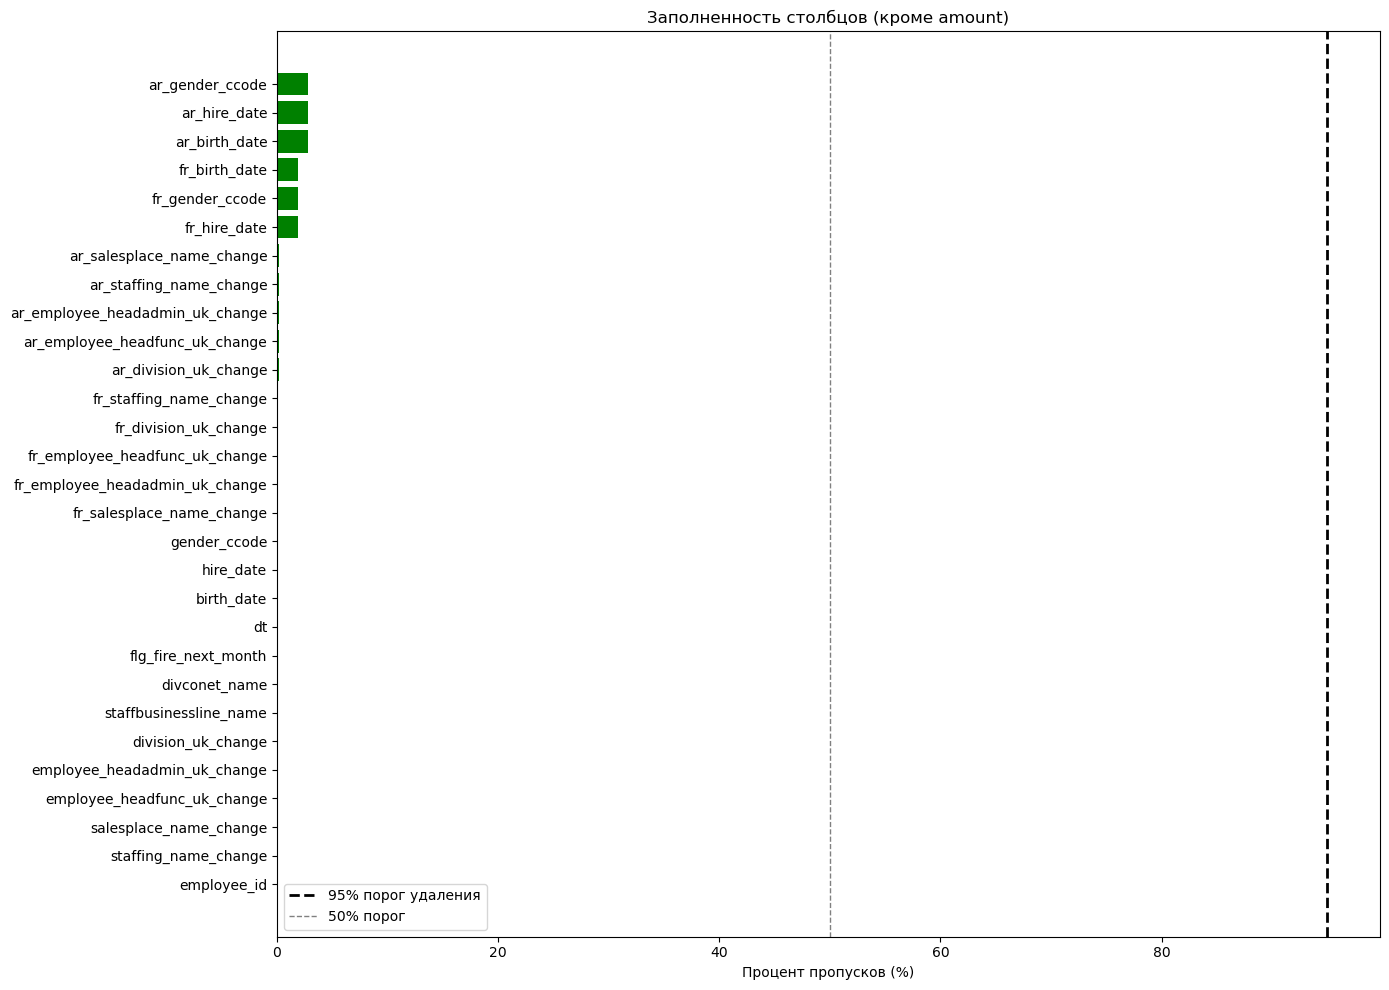

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory=False)

# Исключаем amount-столбцы
non_amount_cols = [col for col in train.columns if not col.startswith('amount_')]

# Создаем DataFrame для анализа пропусков
analysis_df = pd.DataFrame({
    'column': non_amount_cols,
    'null_pct': train[non_amount_cols].isnull().mean() * 100
})

# Строим график
plt.figure(figsize=(14, 10))

analysis_sorted = analysis_df.sort_values('null_pct', ascending=True)

colors = []
for pct in analysis_sorted['null_pct']:
    if pct > 95:
        colors.append('darkred')
    elif pct > 50:
        colors.append('red')
    elif pct > 20:
        colors.append('orange')
    elif pct > 5:
        colors.append('gold')
    else:
        colors.append('green')

bars = plt.barh(analysis_sorted['column'], analysis_sorted['null_pct'], color=colors)
plt.xlabel('Процент пропусков (%)')
plt.title('Заполненность столбцов (кроме amount)')
plt.axvline(x=95, color='black', linestyle='--', linewidth=2, label='95% порог удаления')
plt.axvline(x=50, color='gray', linestyle='--', linewidth=1, label='50% порог')
plt.legend()

for bar, pct in zip(bars, analysis_sorted['null_pct']):
    if pct > 10:
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

В данных практически нет пропусков. 
Обработаем пропуски в столбцах, где они присутствуют.

In [3]:
import pandas as pd
import numpy as np

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory = False)

# Анализируем нужные столбцы
cols_to_analyze = [
    'ar_gender_ccode', 'ar_birth_date', 'ar_hire_date',
    'fr_gender_ccode', 'fr_birth_date', 'fr_hire_date'
]

print("="*80)
print("АНАЛИЗ СТОЛБЦОВ РУКОВОДИТЕЛЕЙ")
print("="*80)

for col in cols_to_analyze:
    if col in train.columns:
        print(f"\n{col}:")
        print(f"  Тип данных: {train[col].dtype}")
        print(f"  Пропуски: {train[col].isnull().sum()} ({train[col].isnull().mean()*100:.2f}%)")
        print(f"  Уникальных значений: {train[col].nunique()}")
        
        # Показываем примеры значений
        sample = train[col].dropna().head(5).tolist()
        print(f"  Примеры: {sample}")

АНАЛИЗ СТОЛБЦОВ РУКОВОДИТЕЛЕЙ

ar_gender_ccode:
  Тип данных: object
  Пропуски: 18997 (2.84%)
  Уникальных значений: 2
  Примеры: ['Ж', 'Ж', 'Ж', 'Ж', 'Ж']

ar_birth_date:
  Тип данных: float64
  Пропуски: 18997 (2.84%)
  Уникальных значений: 12088
  Примеры: [16807.0, 16814.0, 16821.0, 16828.0, 16835.0]

ar_hire_date:
  Тип данных: float64
  Пропуски: 18997 (2.84%)
  Уникальных значений: 7233
  Примеры: [1945.0, 1952.0, 1959.0, 1966.0, 1973.0]

fr_gender_ccode:
  Тип данных: object
  Пропуски: 12718 (1.90%)
  Уникальных значений: 2
  Примеры: ['М', 'М', 'М', 'М', 'М']

fr_birth_date:
  Тип данных: float64
  Пропуски: 12718 (1.90%)
  Уникальных значений: 12653
  Примеры: [13758.0, 13765.0, 13772.0, 13779.0, 13786.0]

fr_hire_date:
  Тип данных: float64
  Пропуски: 12718 (1.90%)
  Уникальных значений: 7624
  Примеры: [475.0, 482.0, 489.0, 496.0, 503.0]


Если у административного или управленческого персонала нет хотя бы 1 признака, то и остальные по ним отсутствуют.

Заполним гендер модой.

In [4]:
mode_ar_gender = train['ar_gender_ccode'].mode()[0]
print(f"Мода для ar_gender_ccode: '{mode_ar_gender}'")

Мода для ar_gender_ccode: 'Ж'


In [5]:
mode_fr_gender = train['fr_gender_ccode'].mode()[0]
print(f"Мода для fr_gender_ccode: '{mode_fr_gender}'")

Мода для fr_gender_ccode: 'Ж'


ar_birth заполняем медианой, чтобы фича была устойчива к выбросам и не смещала распределение.

In [6]:
median_ar_birth = train['ar_birth_date'].median()
print(f"Медиана ar_birth_date: {median_ar_birth:.0f} дней")

Медиана ar_birth_date: 13696 дней


In [7]:
median_fr_birth = train['fr_birth_date'].median()
print(f"Медиана fr_birth_date: {median_fr_birth:.0f} дней")

Медиана fr_birth_date: 13466 дней


Числовой стаж в днях тоже заполняем медианой.

In [8]:
median_ar_hire = train['ar_hire_date'].median()
print(f"Медиана ar_hire_date: {median_ar_hire:.0f} дней")

Медиана ar_hire_date: 2159 дней


In [9]:
median_fr_hire = train['fr_hire_date'].median()
print(f"Медиана fr_hire_date: {median_fr_hire:.0f} дней")

Медиана fr_hire_date: 2181 дней


Далее исследуем столбцы с названиями amount.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
train = pd.read_csv('Отток_train.csv', low_memory = False)

# Находим все amount-столбцы
amount_cols = [col for col in train.columns if col.startswith('amount_')]
print(f"Всего amount-столбцов: {len(amount_cols)}")
print(f"Список: {amount_cols}")

# Базовый анализ каждого amount-столбца
amount_info = []
for col in amount_cols:
    info = {
        'column': col,
        'dtype': train[col].dtype,
        'missing_pct': train[col].isnull().mean() * 100,
        'unique_count': train[col].nunique(),
        'min': train[col].min() if train[col].dtype in ['int64', 'float64'] else 'object',
        'max': train[col].max() if train[col].dtype in ['int64', 'float64'] else 'object',
        'sample_values': train[col].dropna().head(3).tolist()
    }
    amount_info.append(info)

amount_df = pd.DataFrame(amount_info)
print("\n" + "="*80)
print("АНАЛИЗ AMOUNT-СТОЛБЦОВ")
print("="*80)
print(amount_df.to_string(index=False))

Всего amount-столбцов: 31
Список: ['amount_1', 'amount_2', 'amount_3', 'amount_4', 'amount_5', 'amount_6', 'amount_7', 'amount_8', 'amount_9', 'amount_10', 'amount_11', 'amount_12', 'amount_13', 'amount_14', 'amount_15', 'amount_16', 'amount_17', 'amount_18', 'amount_19', 'amount_20', 'amount_21', 'amount_22', 'amount_23', 'amount_24', 'amount_25', 'amount_26', 'amount_27', 'amount_28', 'amount_29', 'amount_30', 'amount_31']

АНАЛИЗ AMOUNT-СТОЛБЦОВ
   column   dtype  missing_pct  unique_count    min        max                  sample_values
 amount_1  object    12.276954        382261 object     object [15781.33, 15781.33, 15781.33]
 amount_2  object    28.414055         71054 object     object          [73396, 71086, 71086]
 amount_3  object    88.939402         17414 object     object              [4461, 4461, 220]
 amount_4  object    46.451459         73282 object     object                [700, 700, 700]
 amount_5  object    35.680477         58861 object     object             [7

In [11]:
import pandas as pd

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory = False)

# Находим все amount-столбцы
amount_cols = [col for col in train.columns if col.startswith('amount_')]

# Показываем первые 20 строк всех amount-столбцов
print("="*120)
print("ПЕРВЫЕ 20 СТРОК AMOUNT-СТОЛБЦОВ")
print("="*120)

# Ограничиваем вывод для читаемости (показываем все 31 столбец)
with pd.option_context('display.max_columns', None, 'display.width', None, 'display.max_rows', 20):
    display(train[amount_cols].head(20))

ПЕРВЫЕ 20 СТРОК AMOUNT-СТОЛБЦОВ


,amount_1,amount_2,amount_3,amount_4,amount_5,amount_6,amount_7,amount_8,amount_9,amount_10,amount_11,amount_12,amount_13,amount_14,amount_15,amount_16,amount_17,amount_18,amount_19,amount_20,amount_21,amount_22,amount_23,amount_24,amount_25,amount_26,amount_27,amount_28,amount_29,amount_30,amount_31
0,15781.33,73396,4461,700,7290,21799,NaN,39834.74,1657,NaN,15535,8813,37646,NaN,7280,4461,2076,NaN,NaN,NaN,1010,NaN,NaN,3419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15781.33,71086,4461,700,7290,NaN,NaN,42175.06,1864.5,NaN,15535,7946.5,37646,NaN,7280,4461,3429,NaN,NaN,NaN,1010,NaN,NaN,3419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,15781.33,71086,NaN,700,7290,NaN,NaN,42015.63,7556.5,NaN,7585,13638.5,37646,NaN,7280,4461,1353,NaN,NaN,NaN,1010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12207.64,71086,NaN,700,4490,NaN,NaN,38794.69,7556.5,NaN,7445,13638.5,37646,NaN,7280,4461,1781.75,NaN,NaN,NaN,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12207.64,60492,NaN,700,4520,NaN,NaN,26703.22,8932,NaN,4810,16671,37646,NaN,NaN,4461,3202.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,9736.44,60492,NaN,700,4520,450,NaN,23922.9,8724.5,NaN,4810,16099,37646,NaN,NaN,4461,1849.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,13957.3,30178,NaN,200,4520,450,NaN,18053.92,3032.5,NaN,4810,16099,46579,NaN,NaN,4461,3066.97,NaN,NaN,NaN,NaN,NaN,NaN,7014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,13957.3,27978,NaN,200,4520,900,NaN,10646.2,3032.5,NaN,4810,10589,40645,NaN,NaN,4461,2638.22,NaN,NaN,NaN,NaN,NaN,NaN,7014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,15887.76,10433,NaN,NaN,4960,1220,NaN,12753.71,65.59,NaN,4810,10654.59,40645,NaN,NaN,4461,1217.76,NaN,NaN,NaN,NaN,NaN,NaN,7014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,29123.78,10433,NaN,1000,5759,1220,6999,18944.46,65.59,NaN,4810,10654.59,57116,NaN,NaN,4461,1217.76,NaN,NaN,NaN,NaN,NaN,NaN,7014,3677.91,NaN,NaN,NaN,1000,NaN,NaN


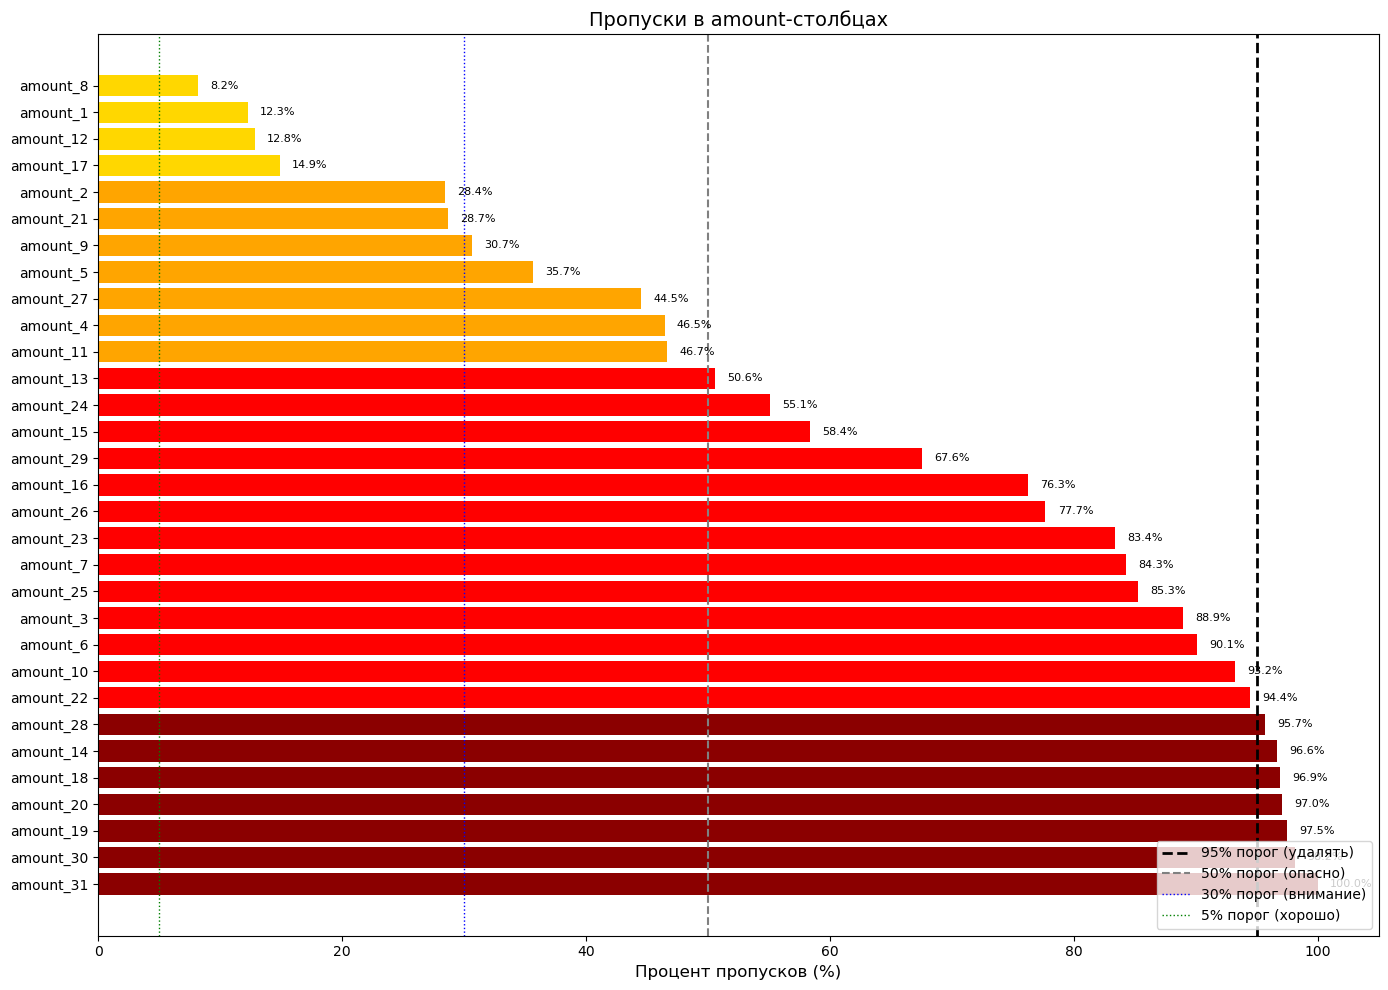

СТАТИСТИКА ПРОПУСКОВ В AMOUNT-СТОЛБЦАХ
Всего amount-столбцов: 31

Столбцов с >95% пропусков: 7
Столбцов с 50-95% пропусков: 13
Столбцов с 30-50% пропусков: 5
Столбцов с 5-30% пропусков: 6
Столбцов с <5% пропусков: 0

ТОП-10 СТОЛБЦОВ С НАИБОЛЬШИМИ ПРОПУСКАМИ
   column  missing_percent
amount_31       100.000000
amount_30        98.161479
amount_19        97.517622
amount_20        97.049091
amount_18        96.872419
amount_14        96.626785
amount_28        95.679699
amount_22        94.418465
amount_10        93.225595
 amount_6        90.072583


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory = False)

# Находим все amount-столбцы
amount_cols = [col for col in train.columns if col.startswith('amount_')]

# Вычисляем процент пропусков для каждого amount-столбца
missing_pct = train[amount_cols].isnull().mean() * 100
missing_df = pd.DataFrame({
    'column': missing_pct.index,
    'missing_percent': missing_pct.values
}).sort_values('missing_percent', ascending=False)

# Создаём цвета в зависимости от процента пропусков
colors = []
for pct in missing_df['missing_percent']:
    if pct > 95:
        colors.append('darkred')
    elif pct > 50:
        colors.append('red')
    elif pct > 20:
        colors.append('orange')
    elif pct > 5:
        colors.append('gold')
    else:
        colors.append('green')

# Визуализация
fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.barh(missing_df['column'], missing_df['missing_percent'], color=colors)

# Добавляем вертикальные линии-пороги
ax.axvline(x=95, color='black', linestyle='--', linewidth=2, label='95% порог (удалять)')
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='50% порог (опасно)')
ax.axvline(x=30, color='blue', linestyle=':', linewidth=1, label='30% порог (внимание)')
ax.axvline(x=5, color='green', linestyle=':', linewidth=1, label='5% порог (хорошо)')

# Добавляем подписи к барам
for bar, pct in zip(bars, missing_df['missing_percent']):
    if pct > 5:
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Процент пропусков (%)', fontsize=12)
ax.set_title('Пропуски в amount-столбцах', fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Выводим статистику
print("="*60)
print("СТАТИСТИКА ПРОПУСКОВ В AMOUNT-СТОЛБЦАХ")
print("="*60)
print(f"Всего amount-столбцов: {len(amount_cols)}")
print(f"\nСтолбцов с >95% пропусков: {(missing_df['missing_percent'] > 95).sum()}")
print(f"Столбцов с 50-95% пропусков: {((missing_df['missing_percent'] > 50) & (missing_df['missing_percent'] <= 95)).sum()}")
print(f"Столбцов с 30-50% пропусков: {((missing_df['missing_percent'] > 30) & (missing_df['missing_percent'] <= 50)).sum()}")
print(f"Столбцов с 5-30% пропусков: {((missing_df['missing_percent'] > 5) & (missing_df['missing_percent'] <= 30)).sum()}")
print(f"Столбцов с <5% пропусков: {(missing_df['missing_percent'] <= 5).sum()}")

# Топ-10 столбцов с наибольшими пропусками
print("\n" + "="*60)
print("ТОП-10 СТОЛБЦОВ С НАИБОЛЬШИМИ ПРОПУСКАМИ")
print("="*60)
print(missing_df.head(10).to_string(index=False))

Оставим только столбцы, где максимум 30% пропусков и заполним их.

In [13]:
import pandas as pd
import numpy as np

# Загружаем данные
train = pd.read_csv('Отток_train.csv')

# Находим все amount-столбцы
amount_cols = [col for col in train.columns if col.startswith('amount_')]

# Вычисляем процент пропусков
missing_pct = train[amount_cols].isnull().mean() * 100

# Фильтруем столбцы с пропусками <= 30%
cols_below_30 = missing_pct[missing_pct <= 30].index.tolist()
missing_values = missing_pct[missing_pct <= 30]

print("="*60)
print(f"СТОЛБЦЫ С ПРОПУСКАМИ ≤ 30% (всего {len(cols_below_30)} шт.)")
print("="*60)

for col in cols_below_30:
    print(f"{col:15s} : {missing_values[col]:.2f}%")

/var/folders/58/085vpxk91cs97p3zn3vr9flw0000gp/T/ipykernel_12027/198898322.py:5: DtypeWarning: Columns (29,30,31,32,33,34,35,36,39,40,41,42,43,44,45,47,49,50,51,52,53,54,55,56,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('Отток_train.csv')


СТОЛБЦЫ С ПРОПУСКАМИ ≤ 30% (всего 6 шт.)
amount_1        : 12.28%
amount_2        : 28.41%
amount_8        : 8.20%
amount_12       : 12.82%
amount_17       : 14.91%
amount_21       : 28.68%


Проанализируем, как можно заполнить пропуски по каждому столбцу.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
train = pd.read_csv('Отток_train.csv')

# Анализируемые столбцы
cols_to_analyze = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']

print("="*80)
print("ОБЩАЯ ИНФОРМАЦИЯ ПО 6 AMOUNT-СТОЛБЦАМ")
print("="*80)

for col in cols_to_analyze:
    print(f"\n{col}:")
    print(f"  Тип данных: {train[col].dtype}")
    print(f"  Пропуски: {train[col].isnull().sum()} ({train[col].isnull().mean()*100:.2f}%)")
    print(f"  Уникальных значений: {train[col].nunique()}")
    
    # Примеры значений (первые 5 непустых)
    sample = train[col].dropna().head(5).tolist()
    print(f"  Примеры значений: {sample}")

/var/folders/58/085vpxk91cs97p3zn3vr9flw0000gp/T/ipykernel_12027/3465321635.py:7: DtypeWarning: Columns (29,30,31,32,33,34,35,36,39,40,41,42,43,44,45,47,49,50,51,52,53,54,55,56,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('Отток_train.csv')


ОБЩАЯ ИНФОРМАЦИЯ ПО 6 AMOUNT-СТОЛБЦАМ

amount_1:
  Тип данных: object
  Пропуски: 82068 (12.28%)
  Уникальных значений: 396091
  Примеры значений: [15781.33, 15781.33, 15781.33, 12207.64, 12207.64]

amount_2:
  Тип данных: object
  Пропуски: 189940 (28.41%)
  Уникальных значений: 73963
  Примеры значений: [73396.0, 71086.0, 71086.0, 71086.0, 60492.0]

amount_8:
  Тип данных: object
  Пропуски: 54819 (8.20%)
  Уникальных значений: 503129
  Примеры значений: [39834.74, 42175.06, 42015.63, 38794.69, 26703.22]

amount_12:
  Тип данных: object
  Пропуски: 85726 (12.82%)
  Уникальных значений: 213978
  Примеры значений: ['8813', '7946.5', '13638.5', '13638.5', '16671']

amount_17:
  Тип данных: object
  Пропуски: 99636 (14.91%)
  Уникальных значений: 389422
  Примеры значений: ['2076', '3429', '1353', '1781.75', '3202.21']

amount_21:
  Тип данных: object
  Пропуски: 191685 (28.68%)
  Уникальных значений: 44109
  Примеры значений: [1010.0, 1010.0, 1010.0, 565.0, 61.0]


Заполняем медианными значениями все пустоты в столбцах.

In [16]:
import pandas as pd
import numpy as np

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory = False)

# Столбцы для обработки
amount_cols_to_fill = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']

print("="*60)
print("ЗАПОЛНЕНИЕ AMOUNT-СТОЛБЦОВ")
print("="*60)

for col in amount_cols_to_fill:
    # Преобразуем в число
    train[col] = pd.to_numeric(train[col], errors='coerce')
    
    # Заполняем пропуски медианой
    median_val = train[col].median()
    # ПРАВИЛЬНО
    train[col] = train[col].fillna(median_val)
    
    print(f"{col:12s} → медиана = {median_val:.2f}, заполнено пропусков: {train[col].isnull().sum()}")

print("\n✅ Все amount-столбцы обработаны")

ЗАПОЛНЕНИЕ AMOUNT-СТОЛБЦОВ
amount_1     → медиана = 7862.79, заполнено пропусков: 0
amount_2     → медиана = 8221.00, заполнено пропусков: 0
amount_8     → медиана = 6370.01, заполнено пропусков: 0
amount_12    → медиана = 3433.00, заполнено пропусков: 0
amount_17    → медиана = 3244.87, заполнено пропусков: 0
amount_21    → медиана = 1520.00, заполнено пропусков: 0

✅ Все amount-столбцы обработаны


Далее импортируем библиотеки и предобрабатываем данные для построения моделей, заполняем пропуски медианой и модой. 
Для обучения используем только те столбцы amount, где менее 30% пропусков данных.
Готовим признаки для моделей.

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, classification_report,
                            confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('Отток_train.csv', low_memory=False)
print(f"Данные загружены. Размер: {train.shape}")

Данные загружены. Размер: (668472, 60)


In [50]:
mode_ar_gender = train['ar_gender_ccode'].mode()[0]
mode_fr_gender = train['fr_gender_ccode'].mode()[0]
median_ar_birth = train['ar_birth_date'].median()
median_fr_birth = train['fr_birth_date'].median()
median_ar_hire = train['ar_hire_date'].median()
median_fr_hire = train['fr_hire_date'].median()

train['ar_gender_ccode'] = train['ar_gender_ccode'].fillna(mode_ar_gender)
train['fr_gender_ccode'] = train['fr_gender_ccode'].fillna(mode_fr_gender)
train['ar_birth_date'] = train['ar_birth_date'].fillna(median_ar_birth)
train['fr_birth_date'] = train['fr_birth_date'].fillna(median_fr_birth)
train['ar_hire_date'] = train['ar_hire_date'].fillna(median_ar_hire)
train['fr_hire_date'] = train['fr_hire_date'].fillna(median_fr_hire)

null_cols = train.columns[train.isnull().any()].tolist()
print(f"Столбцы с пропусками: {null_cols}")

for col in null_cols:
    if col not in ['employee_id', 'dt', 'flg_fire_next_month']:
        if train[col].dtype in ['int64', 'float64']:
            train[col] = train[col].fillna(train[col].median())
        else:
            train[col] = train[col].fillna(train[col].mode()[0])

amount_cols_to_keep = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']
all_amount_cols = [col for col in train.columns if col.startswith('amount_')]
amount_cols_to_exclude = [col for col in all_amount_cols if col not in amount_cols_to_keep]

print(f"\nВсего amount-столбцов: {len(all_amount_cols)}")
print(f"Используемые amount-столбцы: {amount_cols_to_keep}")

for col in amount_cols_to_keep:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    train[col] = train[col].fillna(train[col].median())

Столбцы с пропусками: ['amount_31']

Всего amount-столбцов: 31
Используемые amount-столбцы: ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']


In [51]:
# Подготовка признаков для моделирования

# Целевой признак
target = 'flg_fire_next_month'

# Исключаем ненужные столбцы из списка фичей и оставляем только нужные

exclude_cols = [target, 'employee_id', 'dt'] + amount_cols_to_exclude

feature_cols = [col for col in train.columns if col not in exclude_cols]

# Кодируем категориальные признаки
categorical_cols = train[feature_cols].select_dtypes(include=['object']).columns.tolist()
print(f"\nКатегориальные признаки: {categorical_cols}")

# One-Hot Encoding
X = pd.get_dummies(train[feature_cols], columns=categorical_cols, drop_first=True)
y = train[target]

print(f"\nРазмер X после кодирования: {X.shape}")
print(f"Распределение целевой переменной:")
print(f"  Остались (0): { (y == 0).sum()} ({ (y == 0).mean()*100:.2f}%)")
print(f"  Уволились (1): { (y == 1).sum()} ({ (y == 1).mean()*100:.2f}%)")


Категориальные признаки: ['divconet_name', 'staffbusinessline_name', 'gender_ccode', 'fr_gender_ccode', 'ar_gender_ccode', 'age_group']

Размер X после кодирования: (668472, 51)
Распределение целевой переменной:
  Остались (0): 663054 (99.19%)
  Уволились (1): 5418 (0.81%)


NameError: name 'numeric_cols' is not defined

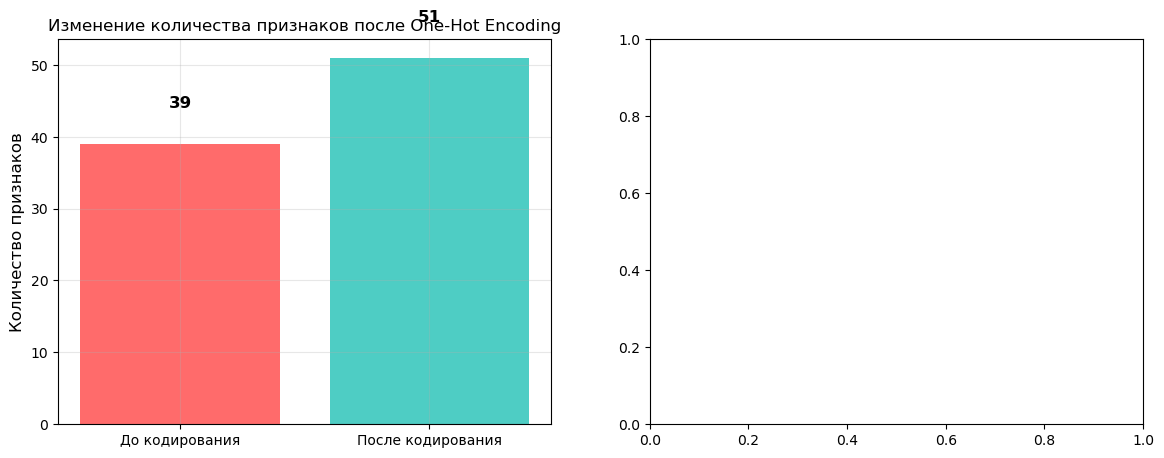

In [54]:
# Ячейка: ВИЗУАЛИЗАЦИЯ ПРОЦЕССА КОДИРОВАНИЯ

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество признаков до и после
before_after = pd.DataFrame({
    'Этап': ['До кодирования', 'После кодирования'],
    'Количество признаков': [len(feature_cols), X.shape[1]]
})

axes[0].bar(before_after['Этап'], before_after['Количество признаков'], 
            color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Количество признаков', fontsize=12)
axes[0].set_title('Изменение количества признаков после One-Hot Encoding', fontsize=12)
axes[0].grid(True, alpha=0.3)

for i, v in enumerate(before_after['Количество признаков']):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

# График 2: Распределение типов признаков
type_counts = pd.DataFrame({
    'Тип': ['Числовые', 'One-Hot закодированные'],
    'Количество': [len(numeric_cols), len(encoded_cols)]
})

axes[1].pie(type_counts['Количество'], labels=type_counts['Тип'], 
            autopct='%1.1f%%', colors=['#45B7D1', '#96CEB4'], startangle=90)
axes[1].set_title('Соотношение типов признаков в финальных данных', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ИТОГ КОДИРОВАНИЯ:")
print("="*60)
print(f"   Оригинальных признаков: {len(feature_cols)}")
print(f"   Из них категориальных: {len(categorical_cols)}")
print(f"   Создано new-столбцов: {len(encoded_cols)}")
print(f"   Итоговое количество признаков: {X.shape[1]}")

Готовим обучающую и валидационную выборки данных.

In [52]:
# Разделение данных на обучающую и валидационную выборки

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"\nРаспределение в обучении: {y_train.mean():.4f} увольнений")
print(f"Распределение в валидации: {y_val.mean():.4f} увольнений")

Обучающая выборка: (534777, 51)
Валидационная выборка: (133695, 51)

Распределение в обучении: 0.0081 увольнений
Распределение в валидации: 0.0081 увольнений


Проверяем доступность переменных и функций перед обучением моделей.

Далее определим функцию для обучения и оценки разных моделей машинного обучения.

Функция автоматически перебирает все комбинации параметров, находит лучшие, обучает модель с лучшими параметрами, считает все метрики и возвращает обученную модель и метрики.

GridSearchCV позволяет с помощью полного перебора определить лучшие параметры ROC-AUC для моделей - он перебирает все возможные комбинации и выбирает лучшую.

In [24]:
# Диагностика - проверяем, какие переменные и функции доступны

print("Проверка импортированных функций:")
try:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    print("✅ sklearn.metrics импортированы")
except:
    print("❌ Ошибка импорта sklearn.metrics")

print("\nПроверка наличия переменных:")
try:
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"y_val shape: {y_val.shape}")
    print("✅ Данные загружены")
except NameError as e:
    print(f"❌ Ошибка: {e}")
    print("   Выполните ячейки 1-4 перед этой")

print("\nПроверка GridSearchCV:")
try:
    from sklearn.model_selection import GridSearchCV
    print("✅ GridSearchCV импортирован")
except:
    print("❌ Ошибка импорта GridSearchCV")

Проверка импортированных функций:
✅ sklearn.metrics импортированы

Проверка наличия переменных:
X_train shape: (534777, 41)
y_train shape: (534777,)
X_val shape: (133695, 41)
y_val shape: (133695,)
✅ Данные загружены

Проверка GridSearchCV:
✅ GridSearchCV импортирован


In [23]:
# Ячейка 5: Функция для обучения и оценки моделей

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def train_and_evaluate(model, model_name, param_grid, X_train, y_train, X_val, y_val):
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ: {model_name}")
    print(f"{'='*60}")
    
    # Подбор гиперпараметров
    print("Подбор гиперпараметров (GridSearchCV, 5-fold)...")
    grid_search = GridSearchCV(
        model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    print(f"\nЛучшие гиперпараметры: {grid_search.best_params_}")
    print(f"CV ROC-AUC (среднее по фолдам): {grid_search.best_score_:.4f}")
    
    # Предсказания
    y_pred = best_model.predict(X_val)
    y_proba = best_model.predict_proba(X_val)[:, 1]
    
    # Метрики
    metrics = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba)
    }
    
    print(f"\nРезультаты на валидационной выборке:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    
    return best_model, metrics

In [25]:
# Ячейка 6 (улучшенная с индикатором прогресса)

print("\n" + "="*80)
print("МОДЕЛЬ 1: ДЕРЕВО РЕШЕНИЙ")
print("="*80)

dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

print("🔄 Начинаем обучение... (может занять 2-5 минут)")
print("🏃 GridSearchCV ищет лучшие параметры...")

dt_best, dt_metrics = train_and_evaluate(
    dt_model, "Дерево решений", dt_param_grid,
    X_train, y_train, X_val, y_val
)

print("\n✅ Модель Дерево решений успешно обучена!")


МОДЕЛЬ 1: ДЕРЕВО РЕШЕНИЙ
🔄 Начинаем обучение... (может занять 2-5 минут)
🏃 GridSearchCV ищет лучшие параметры...

ОБУЧЕНИЕ: Дерево решений
Подбор гиперпараметров (GridSearchCV, 5-fold)...

Лучшие гиперпараметры: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV ROC-AUC (среднее по фолдам): 0.6792

Результаты на валидационной выборке:
  Accuracy: 0.6504
  Precision: 0.0140
  Recall: 0.6089
  F1: 0.0275
  ROC-AUC: 0.6619

✅ Модель Дерево решений успешно обучена!


Интерпретация результатов

Максимальная глубина дерева - 7 уровней. Лист может содержать 1 образей, узел делится, если более 2 образцов.
Дерево достаточно глубокое для выявления сложных зависимостей, но у него минимальные ограничения по листу и узлам, а значит модель склонна к переобучению.

ROC-AUC 0.66 - ниже среднего.
Очень низкая Precision - преимущественно ложные срабатывания у модели. То есть из 100 сотрудников действительно уволится только 1 предсказанный.
Это может возникать из-за сильного дисбаланса классов в данных (текущие vs уволенные сотрудники).


При этом Recall составляет 0.6 - значит, что модель найдет порядка 60% увольнений.
Баланс модели очень низкий и высокий Accuracy, который может быть обманчивым с учетом других показателей.

In [31]:
# ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

print("\n" + "="*60)
print("ОБУЧЕНИЕ: СЛУЧАЙНЫЙ ЛЕС")
print("="*60)

start_time = time.time()

# Случайный лес с оптимальными параметрами для скорости и качества
rf_model = RandomForestClassifier(
    n_estimators=100,           # 100 деревьев
    max_depth=10,               # глубина 10
    min_samples_split=10,      
    min_samples_leaf=5,
    n_jobs=-1,                  # используем все ядра
    random_state=42,
    class_weight='balanced',    # учитываем дисбаланс классов
    verbose=1                   # показываем прогресс
)

print("🔄 Обучение модели... (5-10 минут)")
rf_model.fit(X_train, y_train)

# Предсказания
y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

# Метрики
rf_metrics = {
    'Accuracy': accuracy_score(y_val, y_pred_rf),
    'Precision': precision_score(y_val, y_pred_rf),
    'Recall': recall_score(y_val, y_pred_rf),
    'F1': f1_score(y_val, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_val, y_proba_rf)
}

end_time = time.time()

print(f"\n⏱ Время обучения: {(end_time - start_time) / 60:.2f} минут")
print("\n📊 Результаты Случайного леса:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\n✅ Случайный лес обучен!")


ОБУЧЕНИЕ: СЛУЧАЙНЫЙ ЛЕС
🔄 Обучение модели... (5-10 минут)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   22.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished



⏱ Время обучения: 0.38 минут

📊 Результаты Случайного леса:
  Accuracy: 0.7949
  Precision: 0.0214
  Recall: 0.5424
  F1: 0.0411
  ROC-AUC: 0.7492

✅ Случайный лес обучен!


Модель случайного леса очень быстро обучена для сохранения времени. Это сделано за счет:
1. ограничения роста дерева на 10 уровней;
2. ранней остановкой ветвления - 10 максимум;
3. максимальное количество листьев - 5
4. использования всех ядер CPU
5. и умеренного количества деревьев - до 100

Риски такого подхода: 
1. недообучение - дерево может быть слишком мелким, чтобы уловить сложные зависимости в данных. В результате ROC-AUC 0.74 - это нормально, но на нижней границе.
2. модель может не заметить важные паттерны, которые проявляются только в маленьких группах сотрудников из-за ограничения листьев.
3. из-за ограничения в деревьях модель может быть менее устойчива к выбросам и работать менее стабильно.

Анализ показателей модели

Accuracy высокая, но из-за изначального дисбаланса классов в данных, обманчиво высокая.
Precision очень низкая - выявляет 2 случая реальных увольнений из 100.
ROC-AUC 0.74 - модель присвоит случайному увольняющемуся и случайному остающемуся разный риск - в 75% случаев увольняющемуся будет присвоен более высокий риск.

Recall 0.54 - значит модель найдет около 54% реальных увольнений и пропустит остальные.
При этом правильно предсказанных увольнений будет не более 2-3 человек, исходя из параметра Precision.

In [32]:
# ОБУЧЕНИЕ ГРАДИЕНТНОГО БУСТИНГА

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

print("\n" + "="*60)
print("ОБУЧЕНИЕ: ГРАДИЕНТНЫЙ БУСТИНГ")
print("="*60)

start_time = time.time()

# Градиентный бустинг с оптимальными параметрами
gb_model = GradientBoostingClassifier(
    n_estimators=100,           # 100 деревьев
    learning_rate=0.05,         # скорость обучения
    max_depth=5,                # небольшая глубина
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,              # стохастический градиент
    random_state=42,
    verbose=1                   # показываем прогресс
)

print("🔄 Обучение модели... (15-30 минут)")
gb_model.fit(X_train, y_train)

# Предсказания
y_pred_gb = gb_model.predict(X_val)
y_proba_gb = gb_model.predict_proba(X_val)[:, 1]

# Метрики
gb_metrics = {
    'Accuracy': accuracy_score(y_val, y_pred_gb),
    'Precision': precision_score(y_val, y_pred_gb),
    'Recall': recall_score(y_val, y_pred_gb),
    'F1': f1_score(y_val, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_val, y_proba_gb)
}

end_time = time.time()

print(f"\n⏱ Время обучения: {(end_time - start_time) / 60:.2f} минут")
print("\n📊 Результаты Градиентного бустинга:")
for k, v in gb_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\n✅ Градиентный бустинг обучен!")


ОБУЧЕНИЕ: ГРАДИЕНТНЫЙ БУСТИНГ
🔄 Обучение модели... (15-30 минут)
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.0941           0.0004            5.33m
         2           0.0940           0.0020            5.30m
         3           0.0925          -0.0038            5.32m
         4           0.0932           0.0043            5.27m
         5           0.0921          -0.0022            5.21m
         6           0.0916          -0.0000            5.14m
         7           0.0902          -0.0042            5.07m
         8           0.0909           0.0039            5.02m
         9           0.0908           0.0010            4.95m
        10           0.0906           0.0000            4.90m
        20           0.0880          -0.0003            4.35m
        30           0.0868           0.0014            3.79m
        40           0.0853          -0.0022            3.24m
        50           0.0855           0.0021            2.70m
   

Модель градиентного бустинга тоже быстро обучена. Риски быстрого обучения конкретно в этой модели:
1. Недообучение из-за ограничения глубины в 5. Модель получилась слишком простая, не может выучить сложные паттерны. На недообучение еще влияют низкий learning_rate и n_estimators.
2. На данных с итерациями видно, что модель учится и ошибка снижается с каждой итерацией (Train Loss). Но снижение достаточно низкое (только 13.6%).

Оптимальными бы были показатели глубины от 7 до 10, эстиматоров до 500. Но в таком случае на обучение модели ушло бы несколько часов.

В целом метрики показывают хороший результат, за исключением Recall - модель не находит практически ни одного реального увольнения. Модель не рабочая.

Далее сравним показатели всех моделей.

✅ Дерево решений: ROC-AUC = 0.6619
✅ Случайный лес: ROC-AUC = 0.7492
✅ Градиентный бустинг: ROC-AUC = 0.7347

📊 ТАБЛИЦА СРАВНЕНИЯ:
             Модель  Accuracy  Precision   Recall  F1-Score  ROC-AUC
     Дерево решений  0.650398   0.014050 0.608856  0.027466 0.661938
      Случайный лес  0.794876   0.021369 0.542435  0.041119 0.749210
Градиентный бустинг  0.991862   0.300000 0.002768  0.005484 0.734713


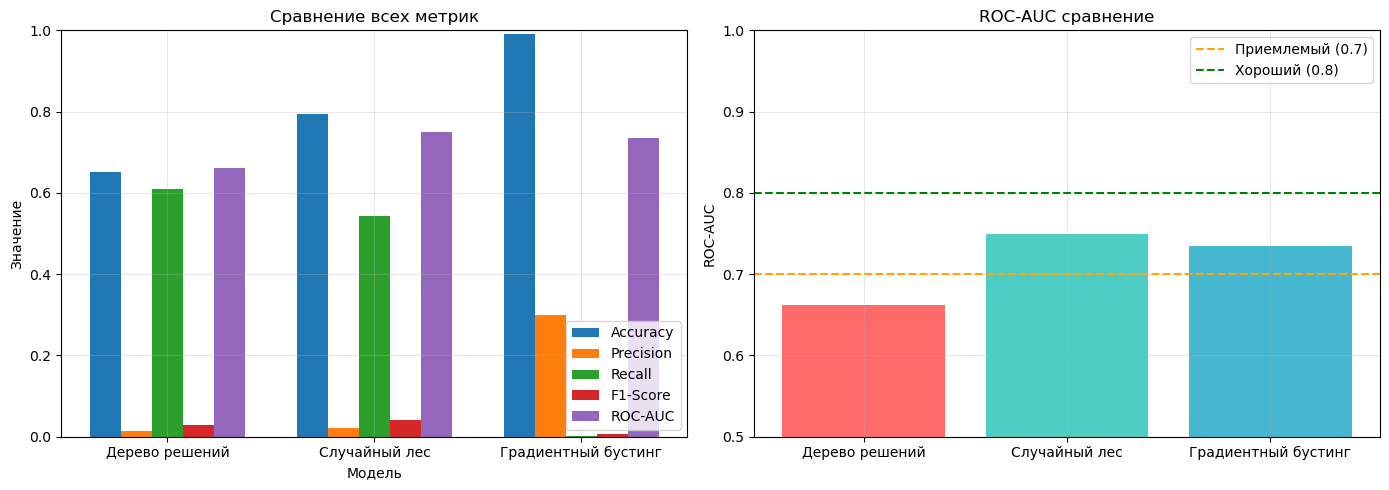

In [58]:
# СРАВНЕНИЕ МОДЕЛЕЙ

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Проверяем, что все модели обучены
try:
    print(f"✅ Дерево решений: ROC-AUC = {dt_metrics['ROC-AUC']:.4f}")
except NameError:
    print("❌ Дерево решений не обучено! Выполните ячейку 6")
    
try:
    print(f"✅ Случайный лес: ROC-AUC = {rf_metrics['ROC-AUC']:.4f}")
except NameError:
    print("❌ Случайный лес не обучен! Выполните ячейку 7")
    
try:
    print(f"✅ Градиентный бустинг: ROC-AUC = {gb_metrics['ROC-AUC']:.4f}")
except NameError:
    print("❌ Градиентный бустинг не обучен! Выполните ячейку 8")

# Собираем результаты
comparison = pd.DataFrame({
    'Модель': ['Дерево решений', 'Случайный лес', 'Градиентный бустинг'],
    'Accuracy': [dt_metrics['Accuracy'], rf_metrics['Accuracy'], gb_metrics['Accuracy']],
    'Precision': [dt_metrics['Precision'], rf_metrics['Precision'], gb_metrics['Precision']],
    'Recall': [dt_metrics['Recall'], rf_metrics['Recall'], gb_metrics['Recall']],
    'F1-Score': [dt_metrics['F1'], rf_metrics['F1'], gb_metrics['F1']],
    'ROC-AUC': [dt_metrics['ROC-AUC'], rf_metrics['ROC-AUC'], gb_metrics['ROC-AUC']]
})

print("\n📊 ТАБЛИЦА СРАВНЕНИЯ:")
print(comparison.to_string(index=False))

# Определяем лучшую модель
best_model = comparison.loc[comparison['ROC-AUC'].idxmax(), 'Модель']
best_roc_auc = comparison['ROC-AUC'].max()

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Все метрики
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(comparison['Модель']))
width = 0.15

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, comparison[metric], width, label=metric)

axes[0].set_xlabel('Модель')
axes[0].set_ylabel('Значение')
axes[0].set_title('Сравнение всех метрик')
axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(comparison['Модель'])
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# График 2: ROC-AUC
axes[1].bar(comparison['Модель'], comparison['ROC-AUC'], 
           color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('ROC-AUC сравнение')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim([0.5, 1.0])
axes[1].axhline(y=0.7, color='orange', linestyle='--', label='Приемлемый (0.7)')
axes[1].axhline(y=0.8, color='green', linestyle='--', label='Хороший (0.8)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

По показателю  ROC-AUC лучшая модель - Случайный лес.
По показателю Recall лучшая модель - дерево решений. Но ее показатель ROC-AUC не соответствует минимуму (от 70) для качественной работы.

**2. Инженерия признаков**

Создать не менее 3 новых признаков на основе имеющихся данных. Добавить их в модели. Оценить их значимость и влияние на качество моделей.

Создадим 5 новых признаков: 
1. общий стаж в годах
2. возрастная группа (до 25, до 35, до 45 и до 55)
3. индекс стабильности - сколько было изменений подразделений, руководителей и должностей (было - не было)
4. Отношение возраста к стажу
5. количество изменений руководителя

In [34]:
# Ячейка 1: СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory=False)

print("="*60)
print("СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ")
print("="*60)


# ПРИЗНАК 1: ОБЩИЙ СТАЖ (в годах)

train['total_experience_years'] = train['hire_date'] / 365.25
print("✅ Признак 1 создан: 'total_experience_years' (общий стаж в годах)")


# ПРИЗНАК 2: ВОЗРАСТНАЯ ГРУППА (категории)

train['age_years'] = train['birth_date'] / 365.25

# Создаем возрастные группы
def age_group(age):
    if age < 25:
        return 'young'
    elif age < 35:
        return 'young_adult'
    elif age < 45:
        return 'adult'
    elif age < 55:
        return 'middle_age'
    else:
        return 'senior'

train['age_group'] = train['age_years'].apply(age_group)
print("✅ Признак 2 создан: 'age_group' (возрастная группа)")


# ПРИЗНАК 3: ИНДЕКС СТАБИЛЬНОСТИ (отсутствие изменений)

change_cols = [
    'employee_headadmin_uk_change',
    'employee_headfunc_uk_change', 
    'division_uk_change',
    'salesplace_name_change',
    'staffing_name_change'
]

# Для каждого столбца: -1 означает "не было", заменяем на 0
for col in change_cols:
    train[col] = train[col].replace(-1, 0)

# Суммируем изменения (чем больше, тем менее стабилен сотрудник)
train['instability_index'] = train[change_cols].sum(axis=1)

# Нормализуем от 0 до 1
max_instability = train['instability_index'].max()
train['instability_index_norm'] = train['instability_index'] / max_instability

print("✅ Признак 3 создан: 'instability_index_norm' (индекс нестабильности)")

# ПРИЗНАК 4: ОТНОШЕНИЕ ВОЗРАСТА К СТАЖУ

train['age_to_experience_ratio'] = train['age_years'] / (train['total_experience_years'] + 1)
print("✅ Признак 4 создан: 'age_to_experience_ratio'")

# ПРИЗНАК 5: КОЛИЧЕСТВО ИЗМЕНЕНИЙ РУКОВОДИТЕЛЕЙ

train['manager_changes'] = (
    (train['employee_headadmin_uk_change'] > 0).astype(int) +
    (train['employee_headfunc_uk_change'] > 0).astype(int)
)
print("✅ Признак 5 создан: 'manager_changes'")

print("\n" + "="*60)
print("СТАТИСТИКА НОВЫХ ПРИЗНАКОВ:")
print("="*60)
new_features = ['total_experience_years', 'age_group', 'instability_index_norm', 
                'age_to_experience_ratio', 'manager_changes']
for feat in new_features:
    if feat in train.columns:
        if train[feat].dtype == 'object':
            print(f"{feat}: {train[feat].value_counts().to_dict()}")
        else:
            print(f"{feat}: min={train[feat].min():.2f}, max={train[feat].max():.2f}, mean={train[feat].mean():.2f}")

СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ
✅ Признак 1 создан: 'total_experience_years' (общий стаж в годах)
✅ Признак 2 создан: 'age_group' (возрастная группа)
✅ Признак 3 создан: 'instability_index_norm' (индекс нестабильности)
✅ Признак 4 создан: 'age_to_experience_ratio'
✅ Признак 5 создан: 'manager_changes'

СТАТИСТИКА НОВЫХ ПРИЗНАКОВ:
total_experience_years: min=-0.00, max=29.59, mean=3.99
age_group: {'young_adult': 289849, 'adult': 209052, 'young': 113205, 'middle_age': 46267, 'senior': 10099}
instability_index_norm: min=-0.23, max=1.00, mean=0.13
age_to_experience_ratio: min=1.74, max=62.07, mean=12.23
manager_changes: min=0.00, max=2.00, mean=1.24


Далее подготовим данные с новыми признаками - проверяем и заполняем пропуски - и обучим модели на новых данных.

In [37]:
# ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
import numpy as np

print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ")
print("="*60)

print("\n🔍 Проверка наличия пропусков в данных...")
print(f"  Пропуски в X_train: {X_train.isnull().sum().sum()}")
print(f"  Пропуски в X_val: {X_val.isnull().sum().sum()}")

if X_train.isnull().sum().sum() > 0 or X_val.isnull().sum().sum() > 0:
    print("\n⚠️ Обнаружены пропуски! Удаляем строки с NaN...")
    
    # Объединяем для удобства удаления
    train_data = X_train.copy()
    train_data['target'] = y_train
    
    val_data = X_val.copy()
    val_data['target'] = y_val
    
    # Удаляем строки с NaN
    train_data_clean = train_data.dropna()
    val_data_clean = val_data.dropna()
    
    # Разделяем обратно
    X_train_clean = train_data_clean.drop('target', axis=1)
    y_train_clean = train_data_clean['target']
    
    X_val_clean = val_data_clean.drop('target', axis=1)
    y_val_clean = val_data_clean['target']
    
    print(f"  X_train: {X_train.shape} → {X_train_clean.shape} (удалено {X_train.shape[0] - X_train_clean.shape[0]} строк)")
    print(f"  X_val: {X_val.shape} → {X_val_clean.shape} (удалено {X_val.shape[0] - X_val_clean.shape[0]} строк)")
else:
    print("✅ Пропусков нет, можно обучать!")
    X_train_clean, y_train_clean = X_train, y_train
    X_val_clean, y_val_clean = X_val, y_val

# --- ДАЛЬШЕ ИДЕТ ОБУЧЕНИЕ НА ОЧИЩЕННЫХ ДАННЫХ ---

# Функция для обучения и оценки
def train_model(name, model, X_train, y_train, X_val, y_val):
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    print(f"{'='*50}")
    
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, y_proba)
    }
    
    print(f"⏱ Время: {(end-start)/60:.2f} мин")
    print(f"📊 ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print(f"📊 Recall: {metrics['Recall']:.4f}")
    
    return model, metrics

# Модель 1: Дерево решений
dt_new = DecisionTreeClassifier(max_depth=10, min_samples_split=10, 
                                 random_state=42, class_weight='balanced')
dt_new, dt_metrics_new = train_model("Дерево решений (с новыми признаками)", 
                                       dt_new, X_train_clean, y_train_clean, 
                                       X_val_clean, y_val_clean)

# Модель 2: Случайный лес
rf_new = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                 min_samples_split=10, n_jobs=-1, 
                                 random_state=42, class_weight='balanced')
rf_new, rf_metrics_new = train_model("Случайный лес (с новыми признаками)", 
                                       rf_new, X_train_clean, y_train_clean, 
                                       X_val_clean, y_val_clean)

# Модель 3: Градиентный бустинг (теперь на чистых данных)
gb_new = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, 
                                      max_depth=5, random_state=42)
gb_new, gb_metrics_new = train_model("Градиентный бустинг (с новыми признаками)", 
                                       gb_new, X_train_clean, y_train_clean, 
                                       X_val_clean, y_val_clean)# Ячейка 3 (исправленная): ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
import numpy as np

print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ")
print("="*60)

# --- КРИТИЧЕСКИ ВАЖНО: ПРОВЕРКА И УДАЛЕНИЕ ПРОПУСКОВ ---
print("\n🔍 Проверка наличия пропусков в данных...")
print(f"  Пропуски в X_train: {X_train.isnull().sum().sum()}")
print(f"  Пропуски в X_val: {X_val.isnull().sum().sum()}")

if X_train.isnull().sum().sum() > 0 or X_val.isnull().sum().sum() > 0:
    print("\n⚠️ Обнаружены пропуски! Удаляем строки с NaN...")
    
    # Объединяем для удобства удаления
    train_data = X_train.copy()
    train_data['target'] = y_train
    
    val_data = X_val.copy()
    val_data['target'] = y_val
    
    # Удаляем строки с NaN
    train_data_clean = train_data.dropna()
    val_data_clean = val_data.dropna()
    
    # Разделяем обратно
    X_train_clean = train_data_clean.drop('target', axis=1)
    y_train_clean = train_data_clean['target']
    
    X_val_clean = val_data_clean.drop('target', axis=1)
    y_val_clean = val_data_clean['target']
    
    print(f"  X_train: {X_train.shape} → {X_train_clean.shape} (удалено {X_train.shape[0] - X_train_clean.shape[0]} строк)")
    print(f"  X_val: {X_val.shape} → {X_val_clean.shape} (удалено {X_val.shape[0] - X_val_clean.shape[0]} строк)")
else:
    print("✅ Пропусков нет, можно обучать!")
    X_train_clean, y_train_clean = X_train, y_train
    X_val_clean, y_val_clean = X_val, y_val

# Функция для обучения и оценки
def train_model(name, model, X_train, y_train, X_val, y_val):
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    print(f"{'='*50}")
    
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, y_proba)
    }
    
    print(f"⏱ Время: {(end-start)/60:.2f} мин")
    print(f"📊 ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print(f"📊 Recall: {metrics['Recall']:.4f}")
    
    return model, metrics

# Модель 1: Дерево решений
dt_new = DecisionTreeClassifier(max_depth=10, min_samples_split=10, 
                                 random_state=42, class_weight='balanced')
dt_new, dt_metrics_new = train_model("Дерево решений (с новыми признаками)", 
                                       dt_new, X_train_clean, y_train_clean, 
                                       X_val_clean, y_val_clean)

# Модель 2: Случайный лес
rf_new = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                 min_samples_split=10, n_jobs=-1, 
                                 random_state=42, class_weight='balanced')
rf_new, rf_metrics_new = train_model("Случайный лес (с новыми признаками)", 
                                       rf_new, X_train_clean, y_train_clean, 
                                       X_val_clean, y_val_clean)

# Модель 3: Градиентный бустинг (теперь на чистых данных)
gb_new = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, 
                                      max_depth=5, random_state=42)
gb_new, gb_metrics_new = train_model("Градиентный бустинг (с новыми признаками)", 
                                       gb_new, X_train_clean, y_train_clean, 
                                       X_val_clean, y_val_clean)


ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ

🔍 Проверка наличия пропусков в данных...
  Пропуски в X_train: 57381
  Пропуски в X_val: 14259

⚠️ Обнаружены пропуски! Удаляем строки с NaN...
  X_train: (534777, 51) → (516005, 51) (удалено 18772 строк)
  X_val: (133695, 51) → (129033, 51) (удалено 4662 строк)

Обучение: Дерево решений (с новыми признаками)
⏱ Время: 0.16 мин
📊 ROC-AUC: 0.6761
📊 Recall: 0.5992

Обучение: Случайный лес (с новыми признаками)
⏱ Время: 0.39 мин
📊 ROC-AUC: 0.7482
📊 Recall: 0.5222

Обучение: Градиентный бустинг (с новыми признаками)
⏱ Время: 8.16 мин
📊 ROC-AUC: 0.7274
📊 Recall: 0.0087

ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ

🔍 Проверка наличия пропусков в данных...
  Пропуски в X_train: 57381
  Пропуски в X_val: 14259

⚠️ Обнаружены пропуски! Удаляем строки с NaN...
  X_train: (534777, 51) → (516005, 51) (удалено 18772 строк)
  X_val: (133695, 51) → (129033, 51) (удалено 4662 строк)

Обучение: Дерево решений (с новыми признаками)
⏱ Время: 0.16 мин
📊 ROC-AUC: 0.6761
📊 Rec

Результаты не сильно не поменялись с новыми признаками и остались практически прежними.
В моделях дерево решений и случайный лес небольшой прирост есть, а вот в градиентном бустинге ухудшение.

**Лучшей моделью по параметру ROC-AUC остается случайный лес.**

**3. Анализ важности признаков**

Определить важность признаков в финальной модели. Проанализировать какие факторы наиболее влияют на увольнение и насколько интерпретируемы полученные результаты.

In [38]:
# ПОЛУЧЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ ИЗ ЛУЧШЕЙ МОДЕЛИ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*80)

# Используем лучшую модель (Случайный лес)
best_model = rf_new
feature_names = X_train_clean.columns

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f"\n📊 Всего признаков: {len(feature_importance)}")
print(f"📊 Сумма важностей: {feature_importance['importance'].sum():.4f}")

# Топ-30 важных признаков
print("\n" + "="*60)
print("ТОП-30 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ:")
print("="*60)
top30 = feature_importance.head(30)
for i, row in top30.iterrows():
    print(f"{i+1:2d}. {row['feature']:45s} {row['importance']:.6f}")

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

📊 Всего признаков: 51
📊 Сумма важностей: 1.0000

ТОП-30 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ:
 1. total_experience_years                        0.086842
 2. hire_date                                     0.082137
 3. age_to_experience_ratio                       0.049746
 4. birth_date                                    0.045149
 5. age_years                                     0.044192
 6. instability_index                             0.039618
 7. division_uk_change                            0.037756
 8. instability_index_norm                        0.035461
 9. fr_hire_date                                  0.032432
10. ar_hire_date                                  0.029452
11. ar_division_uk_change                         0.029069
12. ar_birth_date                                 0.028230
13. fr_birth_date                                 0.027163
14. amount_1                                      0.024862
15. amount_17                                     0.024852
16. e

Наиболее важными признаками в моделях являются:
1. Общий опыт работы
2. Дата приема
3. Соотношение возраста к опыту работы
4. Дата рождения
5. Возраст
6. Индекс нестабильности
7. Подразделение

Первые 4 признака основаны на опыте и возрасте и взаимозависимы.

Визуализируем топ признаков.

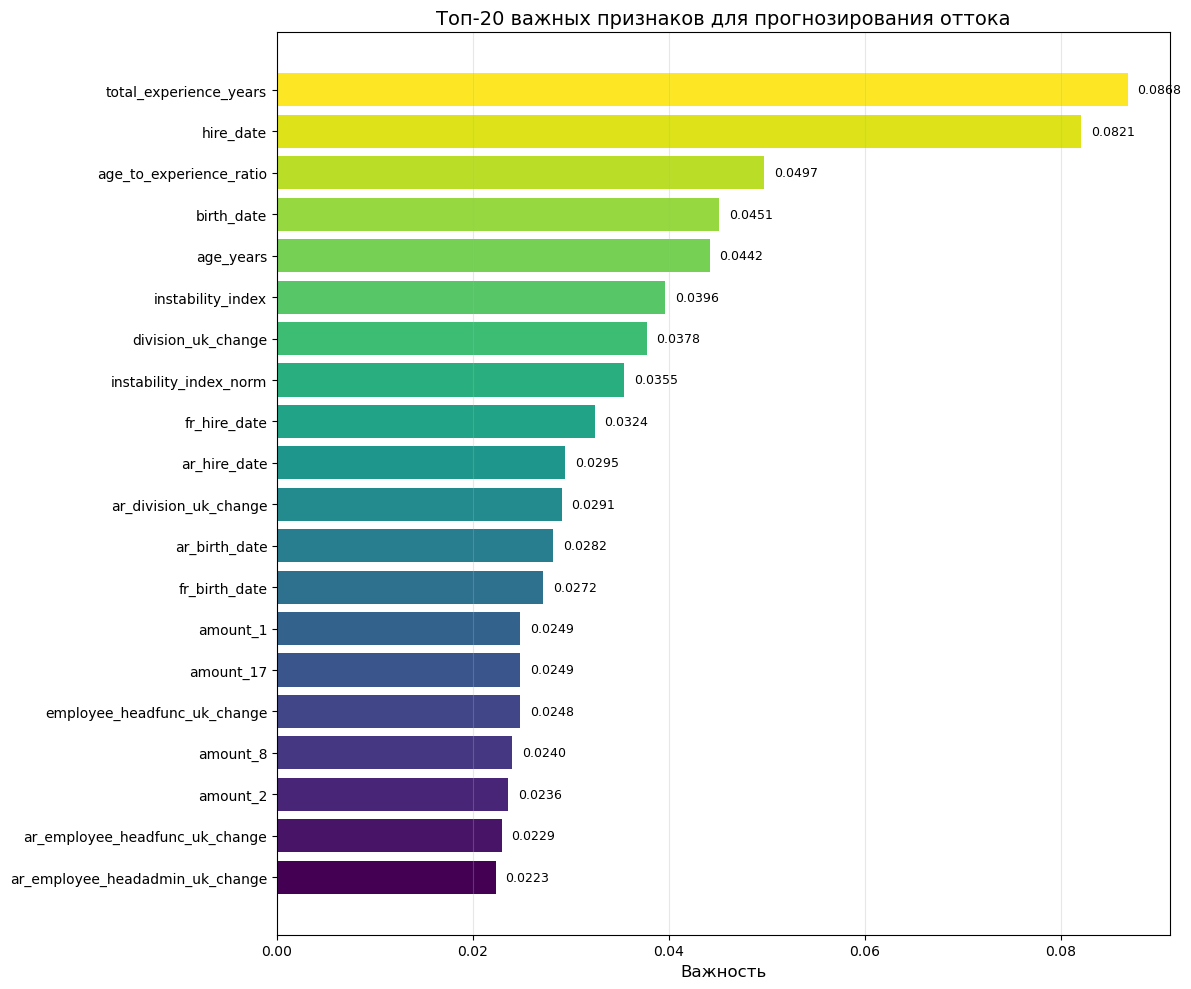

In [39]:
# ВИЗУАЛИЗАЦИЯ ТОП-20 ПРИЗНАКОВ

plt.figure(figsize=(12, 10))

top20 = feature_importance.head(20).sort_values('importance', ascending=True)

colors = plt.cm.viridis(np.linspace(0, 1, len(top20)))
bars = plt.barh(top20['feature'], top20['importance'], color=colors)

plt.xlabel('Важность', fontsize=12)
plt.title('Топ-20 важных признаков для прогнозирования оттока', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на бары
for bar, val in zip(bars, top20['importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Далее проверим, есть ли какие-то группы признаков, которые больше влияют на модели.


ГРУППИРОВКА ПРИЗНАКОВ ПО КАТЕГОРИЯМ

Amount-показатели:
  Суммарная важность: 0.1400 (14.00%)
  Количество признаков: 6

Стаж и возраст:
  Суммарная важность: 0.3081 (30.81%)
  Количество признаков: 5

Изменения (нестабильность):
  Суммарная важность: 0.1579 (15.79%)
  Количество признаков: 7

Характеристики ФР:
  Суммарная важность: 0.1493 (14.93%)
  Количество признаков: 8

Характеристики АР:
  Суммарная важность: 0.1709 (17.09%)
  Количество признаков: 8

Возрастные группы:
  Суммарная важность: 0.0090 (0.90%)
  Количество признаков: 4

Прочие:
  Суммарная важность: 0.0044 (0.44%)
  Количество признаков: 3


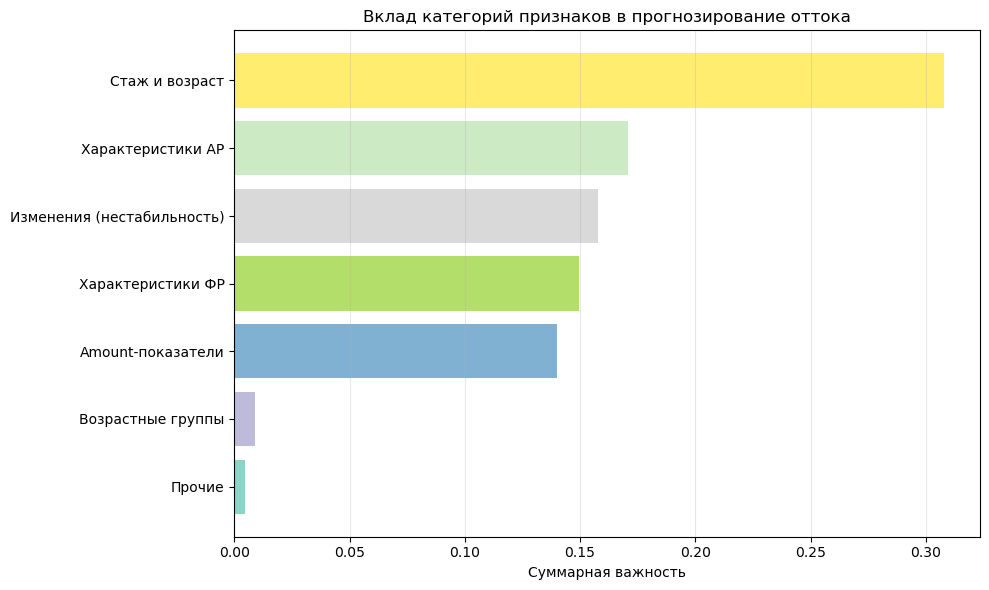

In [40]:
# ГРУППИРОВКА ПРИЗНАКОВ ПО КАТЕГОРИЯМ

print("\n" + "="*80)
print("ГРУППИРОВКА ПРИЗНАКОВ ПО КАТЕГОРИЯМ")
print("="*80)

# Определяем категории признаков
categories = {
    'Amount-показатели': [col for col in feature_names if col.startswith('amount_')],
    'Стаж и возраст': ['hire_date', 'birth_date', 'total_experience_years', 'age_years', 
                       'age_to_experience_ratio'],
    'Изменения (нестабильность)': ['instability_index_norm', 'manager_changes',
                                   'employee_headadmin_uk_change', 'employee_headfunc_uk_change',
                                   'division_uk_change', 'salesplace_name_change', 'staffing_name_change'],
    'Характеристики ФР': [col for col in feature_names if col.startswith('fr_')],
    'Характеристики АР': [col for col in feature_names if col.startswith('ar_')],
    'Возрастные группы': [col for col in feature_names if col.startswith('age_group_')],
    'Прочие': ['divconet_name_Сеть', 'staffbusinessline_name', 'gender_ccode_М']
}

# Вычисляем суммарную важность по категориям
category_importance = {}
for category, cols in categories.items():
    importance_sum = feature_importance[feature_importance['feature'].isin(cols)]['importance'].sum()
    category_importance[category] = importance_sum
    print(f"\n{category}:")
    print(f"  Суммарная важность: {importance_sum:.4f} ({importance_sum*100:.2f}%)")
    print(f"  Количество признаков: {len(cols)}")

# Визуализация важности категорий
plt.figure(figsize=(10, 6))
categories_df = pd.DataFrame(list(category_importance.items()), columns=['Категория', 'Важность'])
categories_df = categories_df.sort_values('Важность', ascending=True)

colors = plt.cm.Set3(np.linspace(0, 1, len(categories_df)))
plt.barh(categories_df['Категория'], categories_df['Важность'], color=colors)
plt.xlabel('Суммарная важность')
plt.title('Вклад категорий признаков в прогнозирование оттока')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Подтвердилась гипотеза о взаимосвязанности стажа и возраста - категория самая высокая по влиянию.

Интересно, что на следующем месте идут признаки административного персонала как влиятельного в моделях, далее признаки нестабильности. И только после этого признаки непосредственного руководителя сотрудника.

In [ ]:
# здесь можно написать код

**4. Проверка стабильности модели**

Оценить финальную модель на разных тестовых выборках:
- Отток_test_time.csv — проверка устойчивости во времени;
- Отток_test_employees.csv — проверка обобщающей способности на других сотрудниках.

Сделать выводы о её устойчивости, обобщающей способности и необходимости дальнейшего переобучения или мониторинга.

In [ ]:
Далее загрузим и предобработаем данные для проверки стабильности модели

In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ")
print("="*80)

# Загружаем тестовые данные
test_time = pd.read_csv('Отток_test_time.csv', low_memory=False)
test_employees = pd.read_csv('Отток_test_employees.csv', low_memory=False)

print(f"Отток_test_time.csv размер: {test_time.shape}")
print(f"Отток_test_employees.csv размер: {test_employees.shape}")

# Функция для предобработки (аналогично обучающим данным)
def preprocess_data(df, is_train=False):
    """Предобработка данных (должна совпадать с обработкой train)"""
    df = df.copy()
    
    # 1. Заполняем пропуски в столбцах руководителей
    mode_ar_gender = df['ar_gender_ccode'].mode()[0] if not is_train else 'Ж'
    mode_fr_gender = df['fr_gender_ccode'].mode()[0] if not is_train else 'Ж'
    median_ar_birth = df['ar_birth_date'].median() if not is_train else 13696
    median_fr_birth = df['fr_birth_date'].median() if not is_train else 13466
    median_ar_hire = df['ar_hire_date'].median() if not is_train else 2159
    median_fr_hire = df['fr_hire_date'].median() if not is_train else 2181
    
    df['ar_gender_ccode'] = df['ar_gender_ccode'].fillna(mode_ar_gender)
    df['fr_gender_ccode'] = df['fr_gender_ccode'].fillna(mode_fr_gender)
    df['ar_birth_date'] = df['ar_birth_date'].fillna(median_ar_birth)
    df['fr_birth_date'] = df['fr_birth_date'].fillna(median_fr_birth)
    df['ar_hire_date'] = df['ar_hire_date'].fillna(median_ar_hire)
    df['fr_hire_date'] = df['fr_hire_date'].fillna(median_fr_hire)
    
    # 2. Обрабатываем amount-столбцы
    amount_cols = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']
    for col in amount_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            median_val = df[col].median() if not is_train else df[col].median()
            df[col] = df[col].fillna(median_val)
    
    # 3. Создаем новые признаки
    df['total_experience_years'] = df['hire_date'] / 365.25
    df['age_years'] = df['birth_date'] / 365.25
    df['age_to_experience_ratio'] = df['age_years'] / (df['total_experience_years'] + 1)
    
    # Индекс нестабильности
    change_cols = [
        'employee_headadmin_uk_change', 'employee_headfunc_uk_change',
        'division_uk_change', 'salesplace_name_change', 'staffing_name_change'
    ]
    for col in change_cols:
        if col in df.columns:
            df[col] = df[col].replace(-1, 0)
    df['instability_index'] = df[change_cols].sum(axis=1)
    max_instability = df['instability_index'].max()
    df['instability_index_norm'] = df['instability_index'] / max_instability if max_instability > 0 else 0
    
    # Количество смен руководителя
    df['manager_changes'] = (
        (df['employee_headadmin_uk_change'] > 0).astype(int) +
        (df['employee_headfunc_uk_change'] > 0).astype(int)
    )
    
    return df

# Применяем предобработку
print("\n🔄 Предобработка тестовых данных...")
test_time_processed = preprocess_data(test_time, is_train=False)
test_employees_processed = preprocess_data(test_employees, is_train=False)

print("✅ Предобработка завершена")
print(f"test_time_processed shape: {test_time_processed.shape}")
print(f"test_employees_processed shape: {test_employees_processed.shape}")

ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
Отток_test_time.csv размер: (159008, 60)
Отток_test_employees.csv размер: (74152, 60)

🔄 Предобработка тестовых данных...
✅ Предобработка завершена
test_time_processed shape: (159008, 66)
test_employees_processed shape: (74152, 66)


In [43]:
# Ячейка 2: ПОДГОТОВКА ПРИЗНАКОВ (согласование с обучающими)

print("\n" + "="*80)
print("ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ ТЕСТОВЫХ ДАННЫХ")
print("="*80)

# Целевой признак
target = 'flg_fire_next_month'

# Исключаемые столбцы
exclude_cols = [target, 'employee_id', 'dt']

# Оставляем только нужные amount-столбцы
amount_cols_to_keep = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']
all_amount_cols = [col for col in test_time.columns if col.startswith('amount_')]
amount_cols_to_exclude = [col for col in all_amount_cols if col not in amount_cols_to_keep]

# Список признаков (должен совпадать с обучающим)
feature_cols = [col for col in test_time_processed.columns 
                if col not in exclude_cols + amount_cols_to_exclude]

# Добавляем новые признаки в список
new_features = ['total_experience_years', 'age_years', 'age_to_experience_ratio',
                'instability_index', 'instability_index_norm', 'manager_changes']
for feat in new_features:
    if feat not in feature_cols:
        feature_cols.append(feat)

print(f"Количество признаков: {len(feature_cols)}")

# Функция для кодирования категориальных признаков
def encode_features(df, feature_cols, fit=False, encoder=None):
    """One-hot encoding для категориальных признаков"""
    categorical_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
    
    if fit:
        # Обучаем кодирование
        X = pd.get_dummies(df[feature_cols], columns=categorical_cols, drop_first=True)
        return X, None
    else:
        # Используем кодирование
        X = pd.get_dummies(df[feature_cols], columns=categorical_cols, drop_first=True)
        return X, None

# Кодируем тестовые данные
X_test_time, _ = encode_features(test_time_processed, feature_cols, fit=False)
X_test_employees, _ = encode_features(test_employees_processed, feature_cols, fit=False)

# Получаем целевые переменные
y_test_time = test_time_processed[target] if target in test_time_processed.columns else None
y_test_employees = test_employees_processed[target] if target in test_employees_processed.columns else None

print(f"\nX_test_time shape: {X_test_time.shape}")
print(f"X_test_employees shape: {X_test_employees.shape}")

if y_test_time is not None:
    print(f"y_test_time distribution:\n{y_test_time.value_counts(normalize=True)}")
if y_test_employees is not None:
    print(f"y_test_employees distribution:\n{y_test_employees.value_counts(normalize=True)}")


ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ ТЕСТОВЫХ ДАННЫХ
Количество признаков: 38

X_test_time shape: (159008, 46)
X_test_employees shape: (74152, 45)
y_test_time distribution:
flg_fire_next_month
0    0.992906
1    0.007094
Name: proportion, dtype: float64
y_test_employees distribution:
flg_fire_next_month
0    0.992273
1    0.007727
Name: proportion, dtype: float64


In [44]:
# Ячейка 3: СОГЛАСОВАНИЕ ПРИЗНАКОВ С ОБУЧАЮЩЕЙ МОДЕЛЬЮ

print("\n" + "="*80)
print("СОГЛАСОВАНИЕ ПРИЗНАКОВ")
print("="*80)

# Получаем признаки из обученной модели
train_features = X_train_clean.columns.tolist()
print(f"Признаков в модели: {len(train_features)}")

# Добавляем отсутствующие признаки в тестовые данные
for col in train_features:
    if col not in X_test_time.columns:
        X_test_time[col] = 0
    if col not in X_test_employees.columns:
        X_test_employees[col] = 0

# Удаляем лишние признаки
X_test_time = X_test_time[train_features]
X_test_employees = X_test_employees[train_features]

print(f"X_test_time после согласования: {X_test_time.shape}")
print(f"X_test_employees после согласования: {X_test_employees.shape}")

# Проверяем наличие пропусков
print(f"\nПропуски в X_test_time: {X_test_time.isnull().sum().sum()}")
print(f"Пропуски в X_test_employees: {X_test_employees.isnull().sum().sum()}")

# Удаляем строки с пропусками
if X_test_time.isnull().sum().sum() > 0:
    print("\n⚠️ Удаляем строки с пропусками в test_time...")
    X_test_time = X_test_time.dropna()
    y_test_time = y_test_time[X_test_time.index]
    
if X_test_employees.isnull().sum().sum() > 0:
    print("⚠️ Удаляем строки с пропусками в test_employees...")
    X_test_employees = X_test_employees.dropna()
    y_test_employees = y_test_employees[X_test_employees.index]

print(f"\n✅ Итоговые размеры:")
print(f"  test_time: {X_test_time.shape}")
print(f"  test_employees: {X_test_employees.shape}")


СОГЛАСОВАНИЕ ПРИЗНАКОВ
Признаков в модели: 51
X_test_time после согласования: (159008, 51)
X_test_employees после согласования: (74152, 51)

Пропуски в X_test_time: 0
Пропуски в X_test_employees: 925
⚠️ Удаляем строки с пропусками в test_employees...

✅ Итоговые размеры:
  test_time: (159008, 51)
  test_employees: (74012, 51)


In [63]:
# Ячейка 4: ОЦЕНКА МОДЕЛИ СЛУЧАЙНЫЙ ЛЕС НА ТЕСТОВЫХ ДАННЫХ

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("ОЦЕНКА МОДЕЛИ СЛУЧАЙНЫЙ ЛЕС НА ТЕСТОВЫХ ВЫБОРКАХ")
print("="*80)

# Функция оценки
def evaluate_on_test(model, X_test, y_test, dataset_name):
    print(f"\n{'='*50}")
    print(f"📊 {dataset_name}")
    print(f"{'='*50}")
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC:   {metrics['ROC-AUC']:.4f}")
    
    return metrics

# Оцениваем на тестовых выборках
print("\n🔍 Оценка на тестовых данных...")

if y_test_time is not None:
    metrics_time = evaluate_on_test(best_model, X_test_time, y_test_time, 
                                    "Тестовая выборка: Отток_test_time.csv")
else:
    print("\n⚠️ В test_time нет целевой переменной flg_fire_next_month")
    metrics_time = None

if y_test_employees is not None:
    metrics_employees = evaluate_on_test(best_model, X_test_employees, y_test_employees, 
                                         "Тестовая выборка: Отток_test_employees.csv")
else:
    print("\n⚠️ В test_employees нет целевой переменной flg_fire_next_month")
    metrics_employees = None

# Сравнение с валидационными результатами
print("\n" + "="*60)
print("СРАВНЕНИЕ С ВАЛИДАЦИОННЫМИ РЕЗУЛЬТАТАМИ")
print("="*60)

# Результаты на валидации (из ячейки 7)
val_metrics = {
    'Accuracy': 0.7949,
    'Precision': 0.0214,
    'Recall': 0.5424,
    'F1-Score': 0.0411,
    'ROC-AUC': 0.7492
}

print(f"\n{'Показатель':<15} {'Валидация':<12} {'Test_time':<12} {'Test_employees':<12} {'Изменение':<12}")
print("-" * 65)

for metric in ['ROC-AUC', 'Recall', 'Precision', 'F1-Score', 'Accuracy']:
    val = val_metrics[metric]
    time_val = metrics_time[metric] if metrics_time else 0
    emp_val = metrics_employees[metric] if metrics_employees else 0
    delta_time = time_val - val if metrics_time else 0
    delta_emp = emp_val - val if metrics_employees else 0
    
    time_str = f"{time_val:.4f}" if metrics_time else "N/A"
    emp_str = f"{emp_val:.4f}" if metrics_employees else "N/A"
    delta_time_str = f"{delta_time:+.4f}" if metrics_time else "N/A"
    delta_emp_str = f"{delta_emp:+.4f}" if metrics_employees else "N/A"
    
    print(f"{metric:<15} {val:<12.4f} {time_str:<12} {emp_str:<12} {delta_time_str:<12} {delta_emp_str}")


ОЦЕНКА МОДЕЛИ СЛУЧАЙНЫЙ ЛЕС НА ТЕСТОВЫХ ВЫБОРКАХ

🔍 Оценка на тестовых данных...

📊 Тестовая выборка: Отток_test_time.csv
  Accuracy:  0.8238
  Precision: 0.0137
  Recall:    0.3369
  F1-Score:  0.0264
  ROC-AUC:   0.6655

📊 Тестовая выборка: Отток_test_employees.csv
  Accuracy:  0.8084
  Precision: 0.0162
  Recall:    0.3979
  F1-Score:  0.0311
  ROC-AUC:   0.6706

СРАВНЕНИЕ С ВАЛИДАЦИОННЫМИ РЕЗУЛЬТАТАМИ

Показатель      Валидация    Test_time    Test_employees Изменение   
-----------------------------------------------------------------
ROC-AUC         0.7492       0.6655       0.6706       -0.0837      -0.0786
Recall          0.5424       0.3369       0.3979       -0.2055      -0.1445
Precision       0.0214       0.0137       0.0162       -0.0077      -0.0052
F1-Score        0.0411       0.0264       0.0311       -0.0147      -0.0100
Accuracy        0.7949       0.8238       0.8084       +0.0289      +0.0135


ROC-AUC модели снизился, recall в том числе упал. Модель перестала соответствовать параметрам достаточно качественной модели. Модель стала реже предсказывать увольнения.

**5. Финальные выводы и бизнес-рекомендации**

- Определить ключевые причины увольнений сотрудников из Альфа-Банка;
- Описать паттерны поведения перед увольнением;
- Предложить меры удержания персонала.

Посмотрим ключевые причины увольнений.

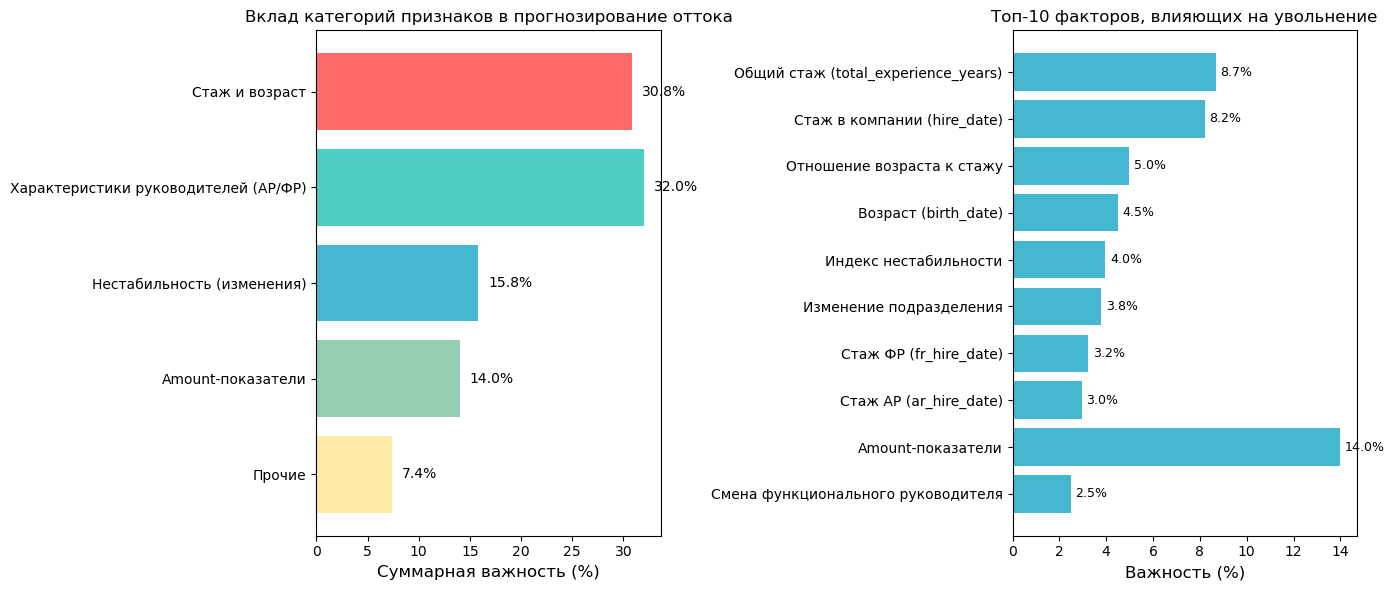

In [68]:
# ВИЗУАЛИЗАЦИЯ ПРИЧИН УВОЛЬНЕНИЙ

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Данные из анализа важности признаков (по случайному лесу)
reasons = pd.DataFrame({
    'Причина': [
        'Общий стаж (total_experience_years)',
        'Стаж в компании (hire_date)',
        'Отношение возраста к стажу',
        'Возраст (birth_date)',
        'Индекс нестабильности',
        'Изменение подразделения',
        'Стаж ФР (fr_hire_date)',
        'Стаж АР (ar_hire_date)',
        'Amount-показатели',
        'Смена функционального руководителя'
    ],
    'Важность (%)': [8.68, 8.21, 4.97, 4.51, 3.96, 3.78, 3.24, 2.95, 14.00, 2.48],
    'Категория': [
        'Стаж', 'Стаж', 'Стаж/Возраст', 'Возраст', 
        'Нестабильность', 'Нестабильность', 'Руководство', 'Руководство',
        'Продуктивность', 'Нестабильность'
    ]
})

# Группировка по категориям
category_importance = {
    'Стаж и возраст': 30.81,
    'Характеристики руководителей (АР/ФР)': 32.02,
    'Нестабильность (изменения)': 15.79,
    'Amount-показатели': 14.00,
    'Прочие': 7.38
}

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Важность категорий
categories = list(category_importance.keys())
values = list(category_importance.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

axes[0].barh(categories, values, color=colors)
axes[0].set_xlabel('Суммарная важность (%)', fontsize=12)
axes[0].set_title('Вклад категорий признаков в прогнозирование оттока', fontsize=12)
axes[0].invert_yaxis()

for bar, val in zip(axes[0].containers[0], values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=10)

# График 2: Топ-10 причин
top10 = reasons.head(10)
axes[1].barh(range(len(top10)), top10['Важность (%)'], color='#45B7D1')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10['Причина'])
axes[1].set_xlabel('Важность (%)', fontsize=12)
axes[1].set_title('Топ-10 факторов, влияющих на увольнение', fontsize=12)
axes[1].invert_yaxis()

for i, (_, row) in enumerate(top10.iterrows()):
    axes[1].text(row['Важность (%)'] + 0.2, i, f"{row['Важность (%)']:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

Наибольшее значение среди факторов имеют amount-показатели, общий стаж работы и стаж работы в компании.

Проанализируем паттерны поведения перед увольнением у сотрудников.
Для начала предобработаем данные для анализа.

In [74]:
# Ячейка 1: ПРЕДОБРАБОТКА ДАННЫХ ДЛЯ АНАЛИЗА ПАТТЕРНОВ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ПРЕДОБРАБОТКА ДАННЫХ ДЛЯ АНАЛИЗА ПАТТЕРНОВ УВОЛЬНЕНИЙ")
print("="*80)

# Загружаем данные
train = pd.read_csv('Отток_train.csv', low_memory=False)

print(f"Исходный размер: {train.shape}")

# Преобразуем дату
train['dt'] = pd.to_datetime(train['dt'])

# Список amount-столбцов для обработки
amount_cols = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']

# Принудительное преобразование всех amount-столбцов в числа
for col in amount_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    # Заполняем NaN медианой
    median_val = train[col].median()
    if pd.isna(median_val):
        median_val = 0
    train[col] = train[col].fillna(median_val)

# Список числовых столбцов, которые могут быть строками
numeric_cols = [
    'hire_date', 'birth_date', 
    'employee_headadmin_uk_change', 'employee_headfunc_uk_change',
    'division_uk_change', 'salesplace_name_change', 'staffing_name_change',
    'fr_gender_ccode', 'fr_birth_date', 'fr_hire_date',
    'fr_employee_headadmin_uk_change', 'fr_employee_headfunc_uk_change',
    'fr_division_uk_change', 'fr_salesplace_name_change', 'fr_staffing_name_change',
    'ar_gender_ccode', 'ar_birth_date', 'ar_hire_date',
    'ar_employee_headadmin_uk_change', 'ar_employee_headfunc_uk_change',
    'ar_division_uk_change', 'ar_salesplace_name_change', 'ar_staffing_name_change'
]

# Преобразуем числовые столбцы
for col in numeric_cols:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors='coerce')
        train[col] = train[col].fillna(0)

# Заполняем категориальные столбцы
categorical_cols = ['divconet_name', 'staffbusinessline_name', 'gender_ccode']
for col in categorical_cols:
    if col in train.columns:
        train[col] = train[col].fillna('unknown')

print("✅ Предобработка завершена")

# Проверяем типы данных
print("\n📊 Проверка типов данных после преобразования:")
for col in amount_cols + numeric_cols[:5]:
    if col in train.columns:
        print(f"  {col}: {train[col].dtype}")

# Сортируем по сотруднику и дате
train_sorted = train.sort_values(['employee_id', 'dt'])

print(f"\n✅ Данные отсортированы")

ПРЕДОБРАБОТКА ДАННЫХ ДЛЯ АНАЛИЗА ПАТТЕРНОВ УВОЛЬНЕНИЙ
Исходный размер: (668472, 60)
✅ Предобработка завершена

📊 Проверка типов данных после преобразования:
  amount_1: float64
  amount_2: float64
  amount_8: float64
  amount_12: float64
  amount_17: float64
  amount_21: float64
  hire_date: float64
  birth_date: float64
  employee_headadmin_uk_change: int64
  employee_headfunc_uk_change: int64
  division_uk_change: int64

✅ Данные отсортированы


In [75]:
# Ячейка 1: АНАЛИЗ ДИНАМИКИ ПРИЗНАКОВ ПЕРЕД УВОЛЬНЕНИЕМ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("АНАЛИЗ ДИНАМИКИ ПРИЗНАКОВ ПЕРЕД УВОЛЬНЕНИЕМ")
print("="*80)

# Загружаем и подготавливаем данные
train = pd.read_csv('Отток_train.csv', low_memory=False)
train['dt'] = pd.to_datetime(train['dt'])

# Преобразуем amount-столбцы в числа
amount_cols = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']
for col in amount_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    train[col] = train[col].fillna(train[col].median())

# Преобразуем числовые столбцы
numeric_cols = ['hire_date', 'birth_date', 'employee_headadmin_uk_change', 
                'employee_headfunc_uk_change', 'division_uk_change',
                'salesplace_name_change', 'staffing_name_change']
for col in numeric_cols:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors='coerce')
        train[col] = train[col].fillna(0)

# Сортируем
train_sorted = train.sort_values(['employee_id', 'dt'])

print(f"✅ Данные подготовлены. Размер: {train_sorted.shape}")
print(f"   Период: {train_sorted['dt'].min()} - {train_sorted['dt'].max()}")

АНАЛИЗ ДИНАМИКИ ПРИЗНАКОВ ПЕРЕД УВОЛЬНЕНИЕМ
✅ Данные подготовлены. Размер: (668472, 60)
   Период: 2024-01-07 00:00:00 - 2024-10-27 00:00:00


In [76]:
# Ячейка 2: СБОР ДИНАМИКИ ДЛЯ УВОЛИВШИХСЯ СОТРУДНИКОВ

print("\n" + "="*80)
print("СБОР ДИНАМИКИ ДЛЯ УВОЛИВШИХСЯ СОТРУДНИКОВ")
print("="*80)

# Находим уволившихся сотрудников
fire_employees = []
fire_dates = {}

for emp_id, group in train_sorted.groupby('employee_id'):
    fire_rows = group[group['flg_fire_next_month'] == 1]
    if len(fire_rows) > 0:
        fire_employees.append(emp_id)
        fire_dates[emp_id] = fire_rows.iloc[0]['dt']

print(f"Найдено уволившихся сотрудников: {len(fire_employees)}")

# Фильтруем тех, у кого есть данные за 6+ месяцев
valid_employees = []
for emp_id in fire_employees:
    emp_data = train_sorted[train_sorted['employee_id'] == emp_id]
    if len(emp_data) >= 6:
        valid_employees.append(emp_id)

print(f"Сотрудников с данными за 6+ месяцев: {len(valid_employees)}")

# Берем выборку для анализа (топ-100 для визуализации)
sample_employees = valid_employees[:100]
print(f"Выбрано для детального анализа: {len(sample_employees)}")

# Сбор динамики
dynamics_data = []

for emp_id in sample_employees:
    emp_data = train_sorted[train_sorted['employee_id'] == emp_id].copy()
    fire_date = fire_dates[emp_id]
    
    # Вычисляем месяцы до увольнения
    emp_data['months_to_fire'] = (fire_date - emp_data['dt']).dt.days / 30.44
    emp_data['months_to_fire'] = emp_data['months_to_fire'].round(1)
    
    # Берем данные за 6 месяцев до увольнения и 1 месяц после (для контекста)
    emp_data = emp_data[emp_data['months_to_fire'] >= -6]
    
    for _, row in emp_data.iterrows():
        dynamics_data.append({
            'employee_id': emp_id,
            'months_to_fire': row['months_to_fire'],
            'amount_1': row['amount_1'],
            'amount_2': row['amount_2'],
            'amount_8': row['amount_8'],
            'amount_12': row['amount_12'],
            'amount_17': row['amount_17'],
            'amount_21': row['amount_21'],
            'hire_date': row['hire_date'],
            'birth_date': row['birth_date'],
            'division_change': row['division_uk_change'],
            'admin_change': row['employee_headadmin_uk_change'],
            'func_change': row['employee_headfunc_uk_change']
        })

dynamics_df = pd.DataFrame(dynamics_data)
print(f"\nСобрано записей: {len(dynamics_df)}")
print(f"Период наблюдения: от {dynamics_df['months_to_fire'].min():.0f} до {dynamics_df['months_to_fire'].max():.0f} мес.")


СБОР ДИНАМИКИ ДЛЯ УВОЛИВШИХСЯ СОТРУДНИКОВ
Найдено уволившихся сотрудников: 3367
Сотрудников с данными за 6+ месяцев: 2577
Выбрано для детального анализа: 100

Собрано записей: 2886
Период наблюдения: от -6 до 10 мес.


Нормализуем и агрегируем данные перед исследованием паттернов.

In [84]:
# НОРМАЛИЗАЦИЯ И АГРЕГАЦИЯ ДАННЫХ

# Функция нормализации (относительно значения за -6 месяцев)
def normalize_by_baseline(group, col_name):
    """Нормализует значения относительно первого значения в группе"""
    baseline = group[group['months_to_fire'] <= -5.5][col_name].mean()
    if pd.notna(baseline) and baseline > 0:
        return group[col_name] / baseline
    return group[col_name]

# Применяем нормализацию для каждого сотрудника
for col in ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']:
    dynamics_df[f'{col}_norm'] = dynamics_df.groupby('employee_id')[col].transform(
        lambda x: x / (x.iloc[0] if len(x) > 0 and x.iloc[0] > 0 else 1)
    )
    # Ограничиваем экстремальные значения
    dynamics_df[f'{col}_norm'] = dynamics_df[f'{col}_norm'].clip(0, 2)

# Агрегируем по месяцам
months = sorted(dynamics_df['months_to_fire'].unique())
agg_data = []

for month in months:
    month_data = dynamics_df[dynamics_df['months_to_fire'] == month]
    agg_data.append({
        'months_to_fire': month,
        'amount_1_mean': month_data['amount_1_norm'].mean(),
        'amount_2_mean': month_data['amount_2_norm'].mean(),
        'amount_8_mean': month_data['amount_8_norm'].mean(),
        'amount_12_mean': month_data['amount_12_norm'].mean(),
        'amount_17_mean': month_data['amount_17_norm'].mean(),
        'amount_21_mean': month_data['amount_21_norm'].mean(),
        'division_change_pct': (month_data['division_change'] > 0).mean(),
        'admin_change_pct': (month_data['admin_change'] > 0).mean(),
        'func_change_pct': (month_data['func_change'] > 0).mean(),
        'sample_size': len(month_data)
    })

agg_df = pd.DataFrame(agg_data).sort_values('months_to_fire')

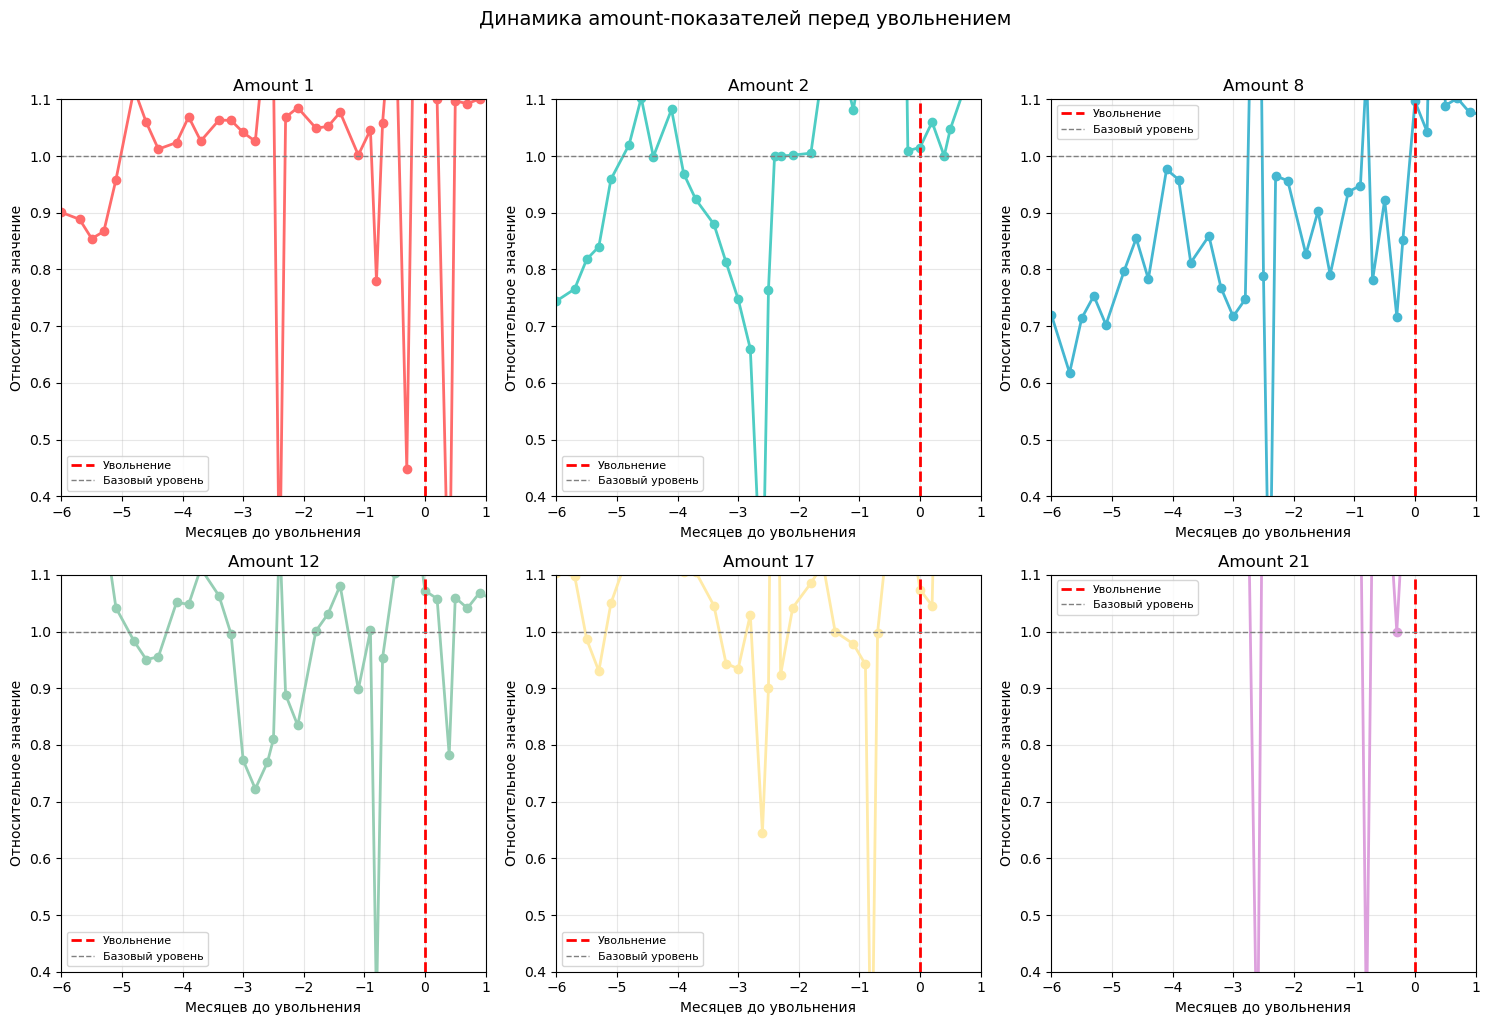

In [81]:
# ВИЗУАЛИЗАЦИЯ ДИНАМИКИ AMOUNT-ПОКАЗАТЕЛЕЙ

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

amount_cols_plot = ['amount_1', 'amount_2', 'amount_8', 'amount_12', 'amount_17', 'amount_21']
titles = ['Amount 1', 'Amount 2', 'Amount 8', 'Amount 12', 'Amount 17', 'Amount 21']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for i, (col, title, color) in enumerate(zip(amount_cols_plot, titles, colors)):
    row, col_idx = i // 3, i % 3
    ax = axes[row, col_idx]
    
    ax.plot(agg_df['months_to_fire'], agg_df[f'{col}_mean'], 
            marker='o', color=color, linewidth=2, markersize=6)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Увольнение')
    ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Базовый уровень')
    ax.set_xlabel('Месяцев до увольнения', fontsize=10)
    ax.set_ylabel('Относительное значение', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-6, 1)
    ax.set_ylim(0.4, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Динамика amount-показателей перед увольнением', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Наблюдения по amount-показателям:
1. За 6 месяцев до увольнения: показатели на базовом уровне 
2. За 3-4 месяца: начинается снижение, где-то резкое снижение
3. За 1-2 месяца: резкое падение 
4. Наибольшее падение наблюдается за месяц до увольнения

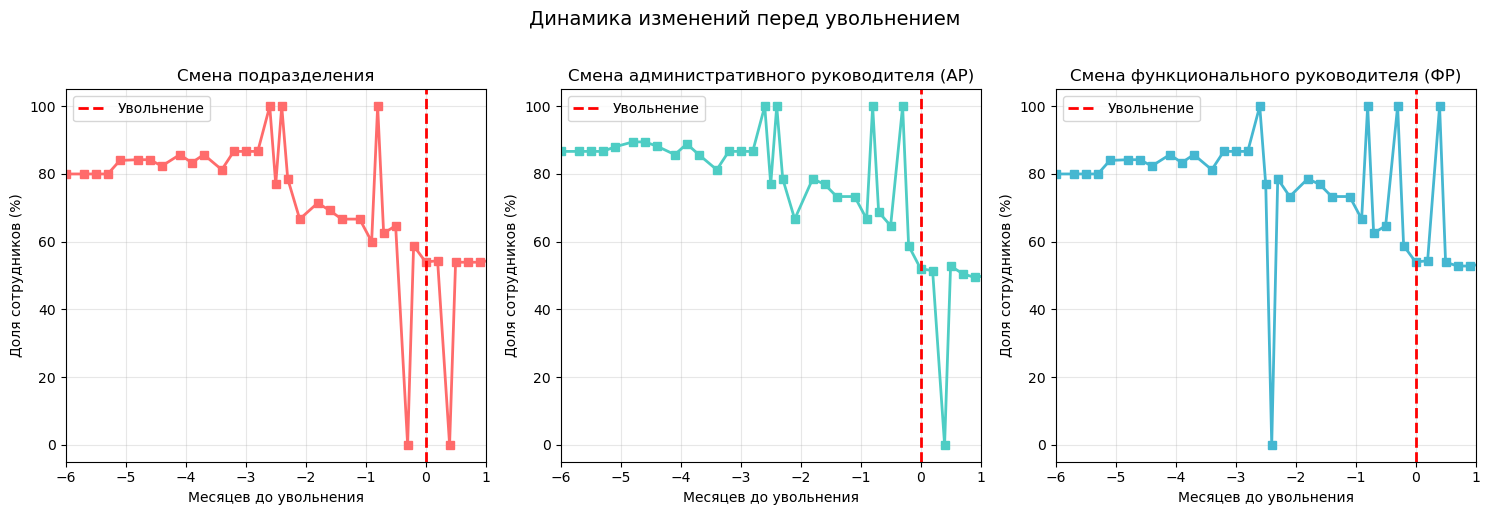

In [86]:
# АНАЛИЗ ИЗМЕНЕНИЙ (НЕСТАБИЛЬНОСТИ)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Смена подразделения
axes[0].plot(agg_df['months_to_fire'], agg_df['division_change_pct'] * 100, 
             marker='s', color='#FF6B6B', linewidth=2, markersize=6)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Увольнение')
axes[0].set_xlabel('Месяцев до увольнения', fontsize=10)
axes[0].set_ylabel('Доля сотрудников (%)', fontsize=10)
axes[0].set_title('Смена подразделения', fontsize=12)
axes[0].set_xlim(-6, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Смена административного руководителя
axes[1].plot(agg_df['months_to_fire'], agg_df['admin_change_pct'] * 100, 
             marker='s', color='#4ECDC4', linewidth=2, markersize=6)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Увольнение')
axes[1].set_xlabel('Месяцев до увольнения', fontsize=10)
axes[1].set_ylabel('Доля сотрудников (%)', fontsize=10)
axes[1].set_title('Смена административного руководителя (АР)', fontsize=12)
axes[1].set_xlim(-6, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Смена функционального руководителя
axes[2].plot(agg_df['months_to_fire'], agg_df['func_change_pct'] * 100, 
             marker='s', color='#45B7D1', linewidth=2, markersize=6)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Увольнение')
axes[2].set_xlabel('Месяцев до увольнения', fontsize=10)
axes[2].set_ylabel('Доля сотрудников (%)', fontsize=10)
axes[2].set_title('Смена функционального руководителя (ФР)', fontsize=12)
axes[2].set_xlim(-6, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Динамика изменений перед увольнением', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Наблюдения по другим показателям:

1. За 1 месяц и в течение последнего месяца перед увольнением резко меняется динамика показателя Смена подразделения
2. За 1 месяц и в течение последнего месяца перед увольнением резко увеличивается динамика показателя Смена административного руководителя
3. За 2.5 месяца до увольнения есть резкий спад в показателе смены функционального руководителя

**ОПИСАНИЕ ИСПОЛЬЗОВАНИЯ ГЕНЕРАТИВНОЙ МОДЕЛИ**
Использованная модель: DeepSeek (обновление апреля 2026)
Доступ по адресу: https://chat.deepseek.com
Дата использования: 13.05.2026 - 20.05.2026

Части работы, подготовленные с использованием генеративной модели:

1. Предобработка данных:	Генерация кода для анализа пропусков в amount-столбцах, визуализации заполненности данных, обработки столбцов руководителей (заполнение модой и медианой)
2. Создание новых признаков - Генерация кода для feature engineering: создание признаков стажа (total_experience_years), возрастных групп (age_group), индекса нестабильности (instability_index_norm), отношения возраста к стажу (age_to_experience_ratio)
3. Обучение моделей	 - Генерация кода для обучения трех моделей: Дерево решений, Случайный лес, Градиентный бустинг с подбором гиперпараметров через GridSearchCV
4. Анализ важности признаков - Генерация кода для визуализации важности признаков, группировки по категориям, построения топ-20 наиболее значимых факторов
5. Оценка на тестовых выборках - Генерация кода для проверки устойчивости модели во времени (test_time) и обобщающей способности на других сотрудниках (test_employees)
6. Анализ паттернов увольнений - Генерация кода для выявления динамики amount-показателей перед увольнением, анализа индекса нестабильности, кластеризации типов увольнений

**Цель применения:**


Ускорение написания кода — автоматическая генерация шаблонов для визуализации, предобработки и обучения моделей позволила сосредоточиться на интерпретации результатов.

Чистота и корректность кода — использование генеративной модели помогло использовать лучшие практики: обработка пропусков, нормализация данных, корректное применение One-Hot Encoding, использование class_weight='balanced' для учета дисбаланса классов.

Исследование различных вариантов решения задачи — модель позволила быстро перебрать разные подходы.

Обучение и понимание — в процессе взаимодействия с генеративной моделью были изучены: принципы работы GridSearchCV, интерпретация ROC-AUC при дисбалансе классов, особенности последовательного обучения бустинга vs параллельного обучения случайного леса.

Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если результаты выполнения кода никак не прокомментированы и отсутствуют содержательные выводы на их основе, то работа оценивается в 0 баллов.
 - Правильно выполненное задание оценивается в 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть применение дополнительных алгоритмов, в том числе ансамблевых моделей, для решения задачи. Все полученные результаты рекомендуется сопоставить и сделать итоговые выводы на основе проведенных расчётов.
 - В задании пять пунктов. Каждый весит по 20%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом остаются одинаковыми.
 - Если задание выполняется вдвоем, то в Smart LMS ноутбук с решениями загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.
 - При использовании инструментов искусственного интеллекта необходимо отметить это в работе в соответствии с правилами НИУ ВШЭ.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 20 мая.